# Task 1A, Step 1 -- Default plot lookup table: visual test cases

A couple of things discovered while assembling this notebook:

- `BoxModel([1,2,3,4,5,6]).sim(10).plot()` (calling `.plot()` directly on a
  probability-space simulation) currently raises: *"Only simulations of random
  variables (RV) can be plotted..."* You have to wrap it: `RV(BoxModel(...)).sim(10)`.
  The test cases below use the `RV(...)` wrapper for that reason.
- `RV(BoxModel(['H', 'T'])).sim(10).plot()` -- a **string-valued** RV -- currently
  raises `AttributeError: 'str' object has no attribute 'plot'` no matter what
  `type=` you pass. In other words: **categorical/string data cannot be plotted
  at all today.** This is a real gap, not a formatting nuance -- it's included
  below so you can see the failure directly, and it should inform the "1D
  categorical/string" row of the lookup table (there is currently no working
  default to fall back to; `classify_data` will need a new code path, e.g. a bar
  chart of value counts, before this row can even have a default).


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from symbulate import *

%matplotlib inline
plt.rcParams['figure.max_open_warning'] = 100


OSError: 'seaborn-colorblind' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [ ]:
def show_types(sim, types, title, ncols=3, figsize_per=(5, 4)):
    """Run sim.plot(type=t) for every t in types, one subplot per type.

    Only safe for 1D data. Errors are caught and printed inside the
    subplot instead of stopping the notebook, so a broken type=...
    combination is itself a visible result rather than a crash.
    """
    n = len(types)
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    axes = np.array(axes).reshape(-1)
    for i, t in enumerate(types):
        plt.sca(axes[i])
        try:
            sim.plot(type=t)
            axes[i].set_title(f"type={t!r}")
        except Exception as e:
            axes[i].set_title(f"type={t!r}  -->  ERROR")
            axes[i].text(0.5, 0.5, str(e), ha='center', va='center',
                         wrap=True, fontsize=8, color='crimson',
                         transform=axes[i].transAxes)
    for j in range(n, len(axes)):
        axes[j].axis('off')
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()


def show_types_2d(sim, types, title):
    """Run sim.plot(type=t) for every t in types, ONE STANDALONE FIGURE PER TYPE.

    Several 2D plot types (hist, density, tile) add their own colorbar via
    fig.add_axes() at a fixed *figure-relative* position. That collides badly
    if multiple such types share one figure/subplot grid (colorbars stack on
    top of each other), and 'marginal' builds its own GridSpec on whatever
    figure is current. Giving each type a fresh figure avoids all of that.
    """
    print(f"--- {title} ---")
    for t in types:
        plt.figure(figsize=(5, 4))
        try:
            sim.plot(type=t)
            plt.title(f"type={t!r}")
        except Exception as e:
            plt.title(f"type={t!r}  -->  ERROR")
            plt.text(0.5, 0.5, str(e), ha='center', va='center',
                     wrap=True, fontsize=8, color='crimson',
                     transform=plt.gca().transAxes)
        plt.tight_layout()
        plt.show()

ONE_D_TYPES = ['impulse', 'hist', 'bar', 'density', 'ecdf', 'rug',
               ('hist', 'rug'), ('density', 'rug')]

TWO_D_TYPES = ['scatter', 'hist', 'density', 'tile', 'violin', 'mosaic',
               'marginal', ('scatter', 'marginal'), ('density', 'marginal'),
               ('hist', 'marginal')]


## 1D discrete-ish, small n (n=10)

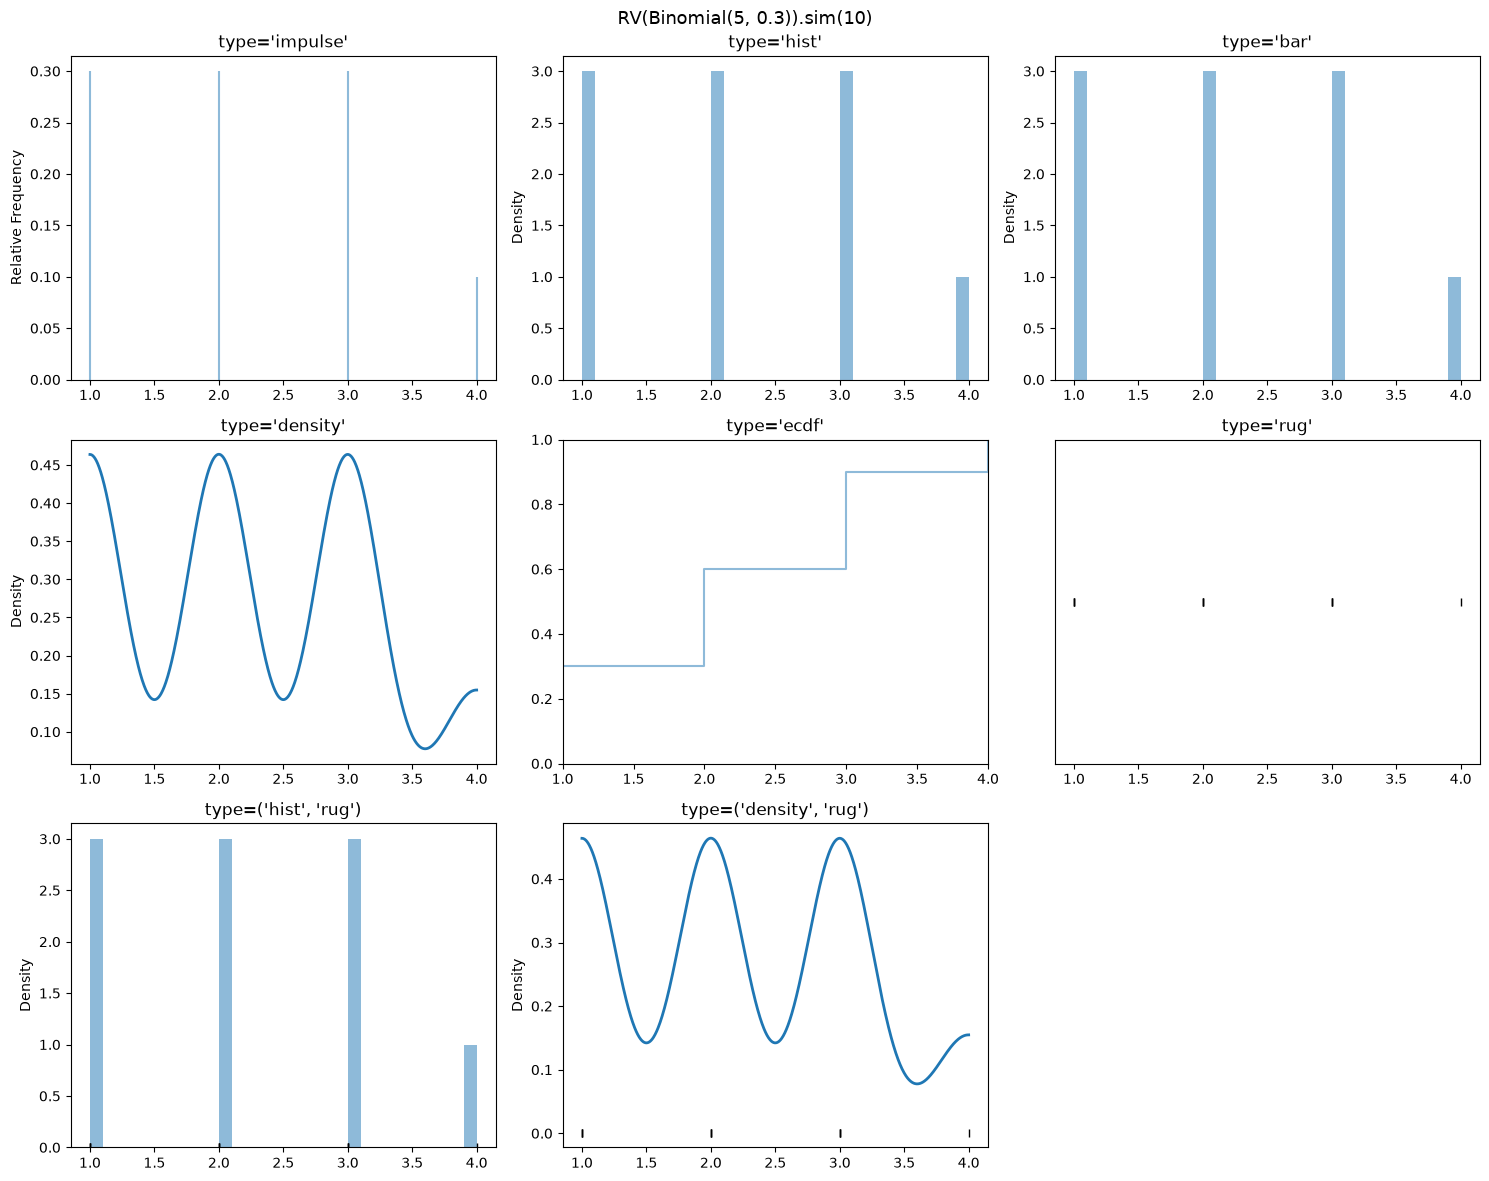

In [ ]:
show_types(RV(Binomial(5, 0.3)).sim(10), ONE_D_TYPES,
           "RV(Binomial(5, 0.3)).sim(10)")

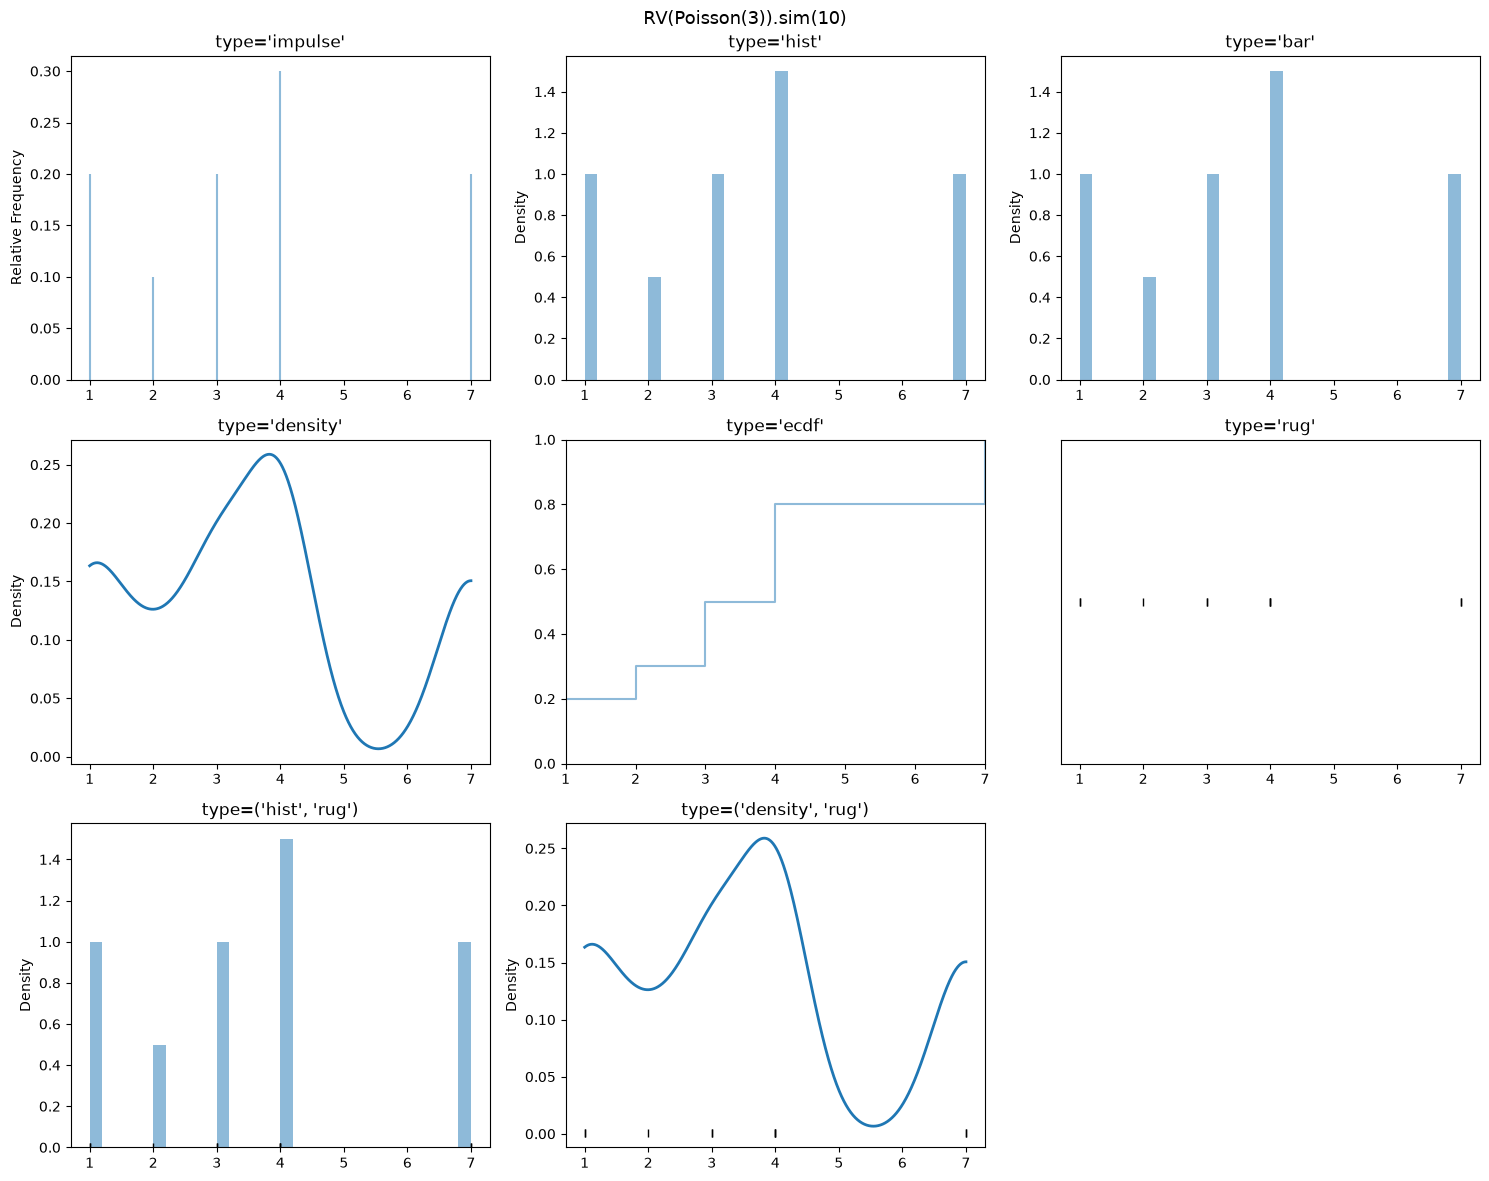

In [ ]:
show_types(RV(Poisson(3)).sim(10), ONE_D_TYPES,
           "RV(Poisson(3)).sim(10)")

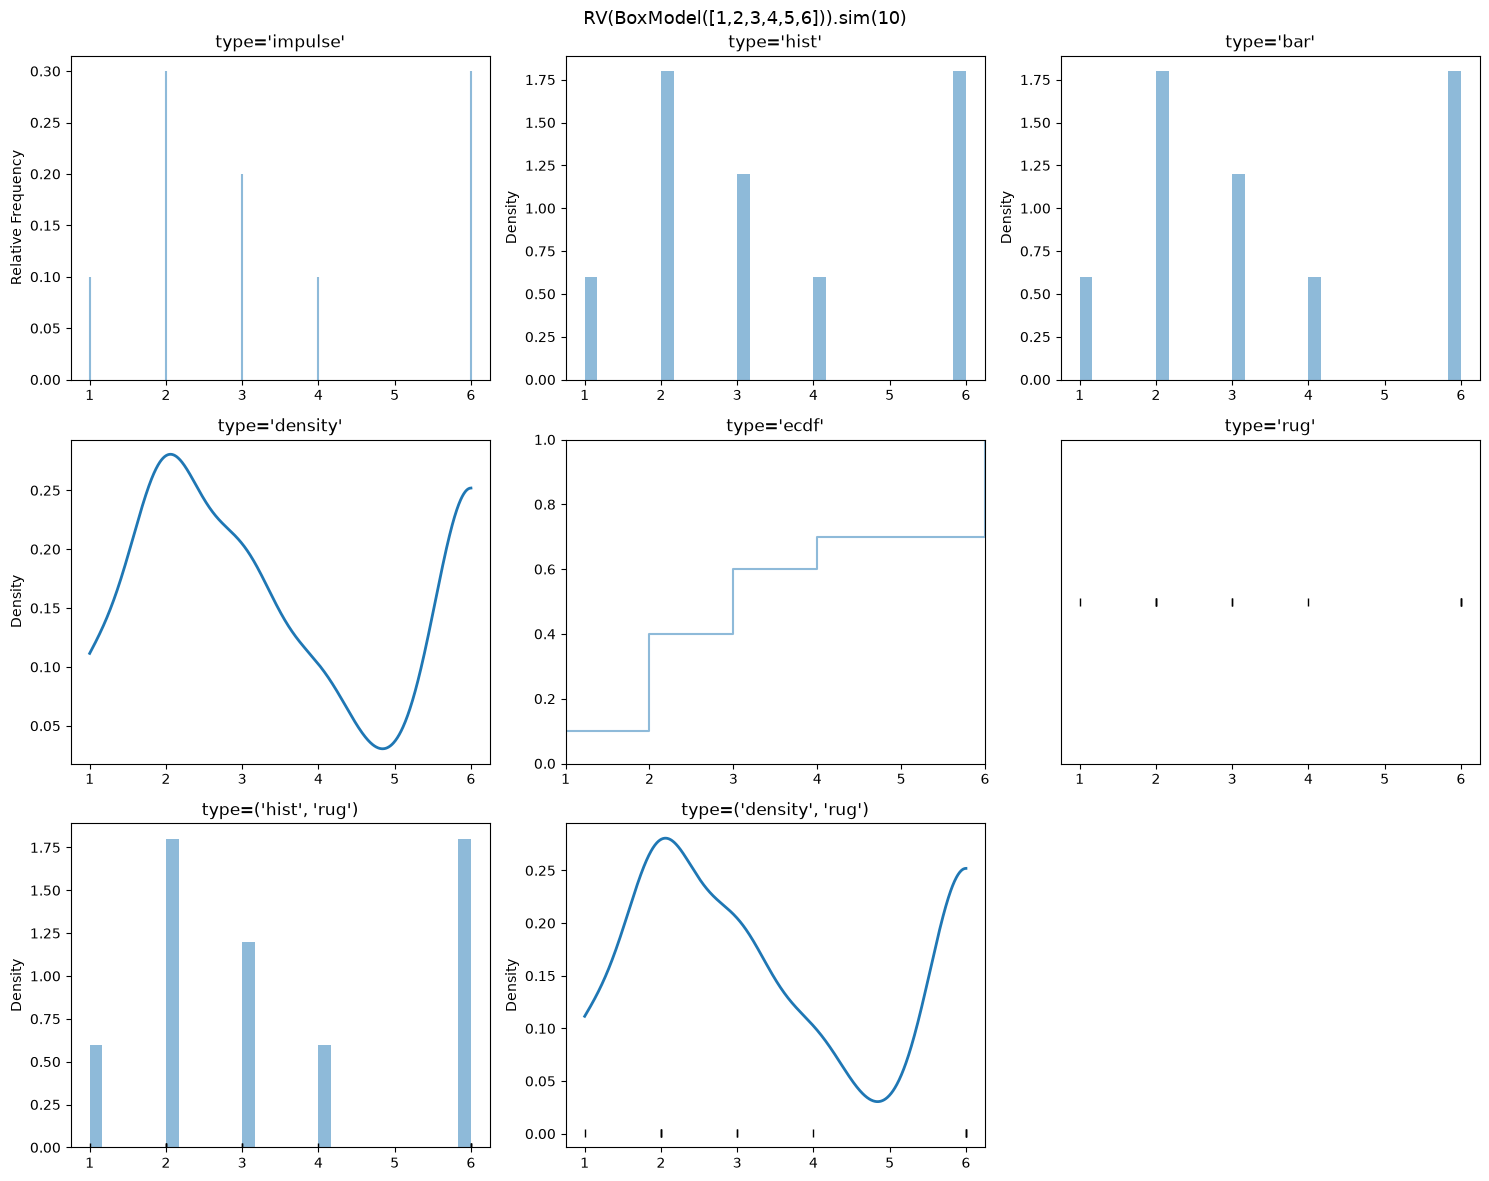

In [ ]:
show_types(RV(BoxModel([1, 2, 3, 4, 5, 6])).sim(10), ONE_D_TYPES,
           "RV(BoxModel([1,2,3,4,5,6])).sim(10)")

**Also try the calls exactly as written in the task** (no `type=` argument,
default behavior; and the raw non-RV call to confirm the error described above):

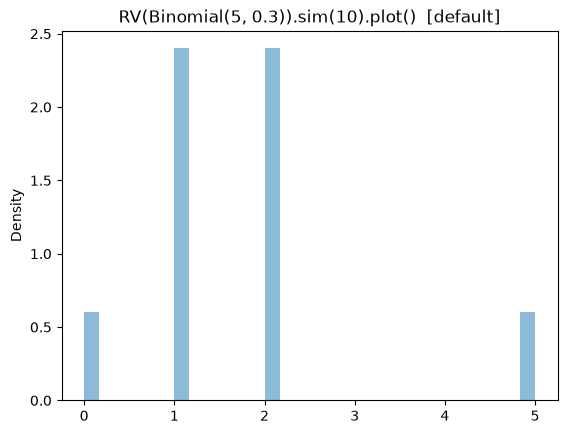

In [ ]:
RV(Binomial(5, 0.3)).sim(10).plot()
plt.title("RV(Binomial(5, 0.3)).sim(10).plot()  [default]")
plt.show()

In [ ]:
try:
    BoxModel([1, 2, 3, 4, 5, 6]).sim(10).plot()
except Exception as e:
    print("BoxModel([1,2,3,4,5,6]).sim(10).plot() raised:", e)

BoxModel([1,2,3,4,5,6]).sim(10).plot() raised: Only simulations of random variables (RV) can be plotted, but you simulated from a probability space. You must first define a RV on your probability space and simulate it. Then call .plot() on those simulations.


_Your notes -- best default / reasonable alternatives for 1D discrete-ish, small n:_\n\n- 

## 1D discrete-ish, large n (n=10000)

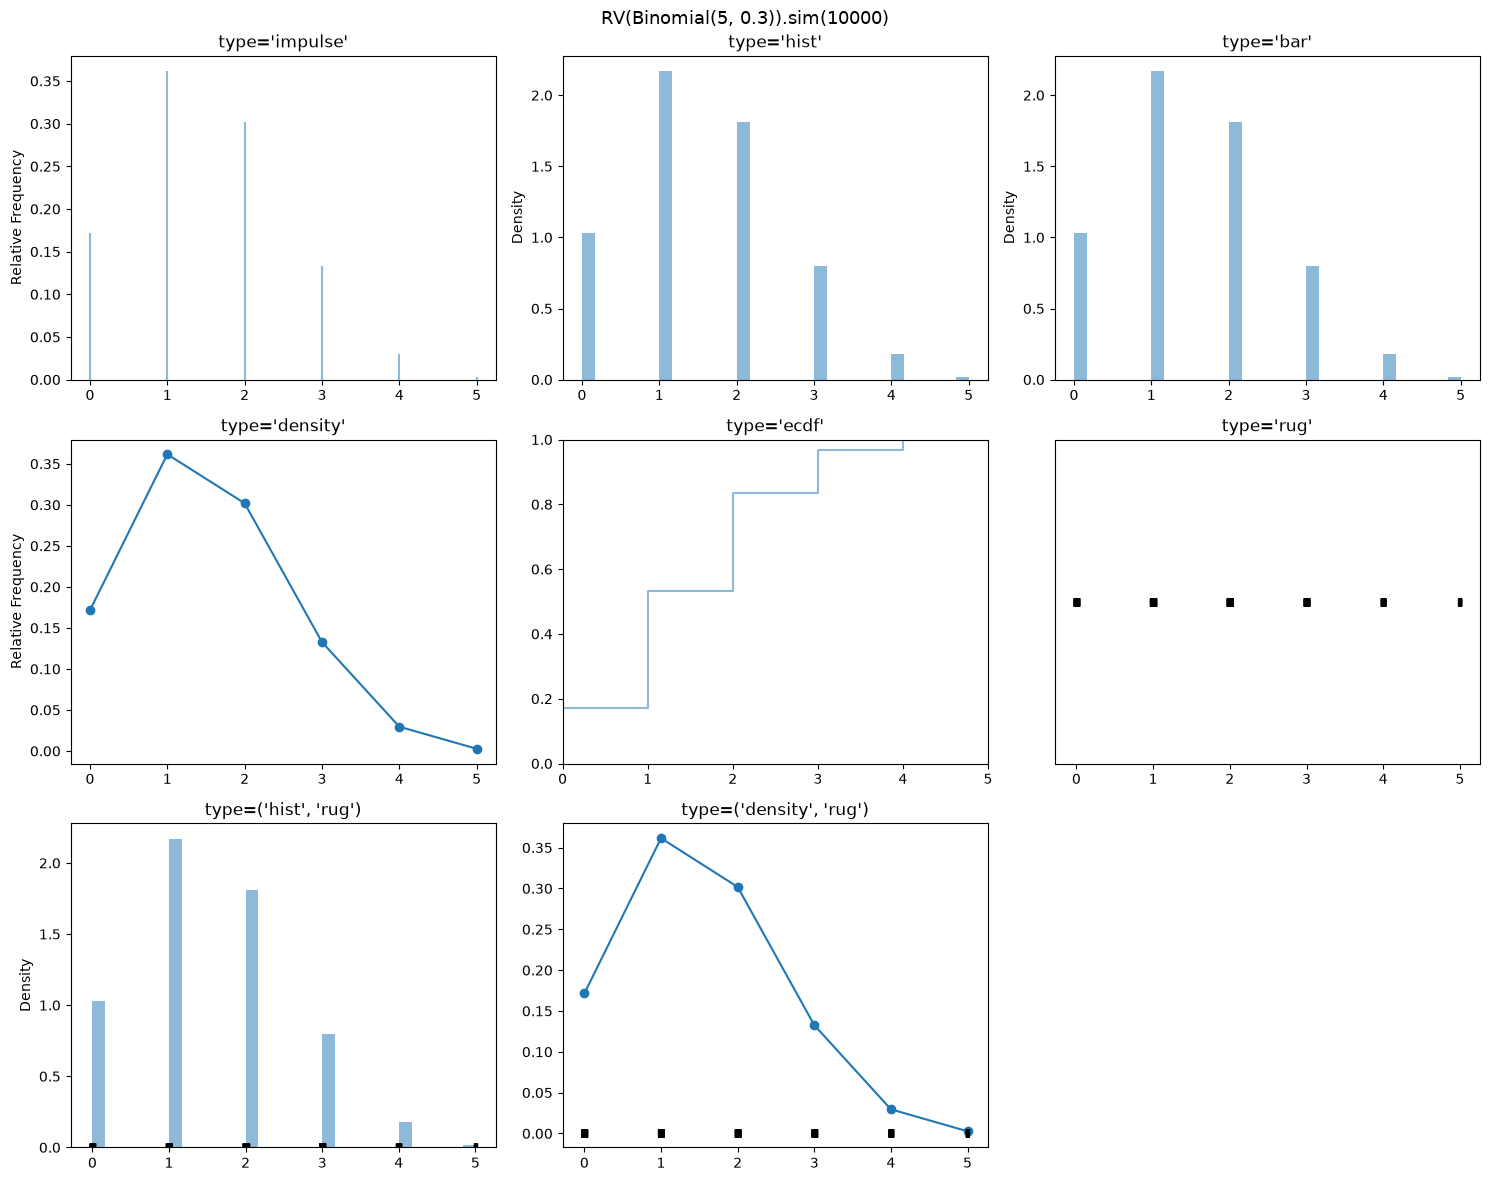

In [ ]:
show_types(RV(Binomial(5, 0.3)).sim(10000), ONE_D_TYPES,
           "RV(Binomial(5, 0.3)).sim(10000)")

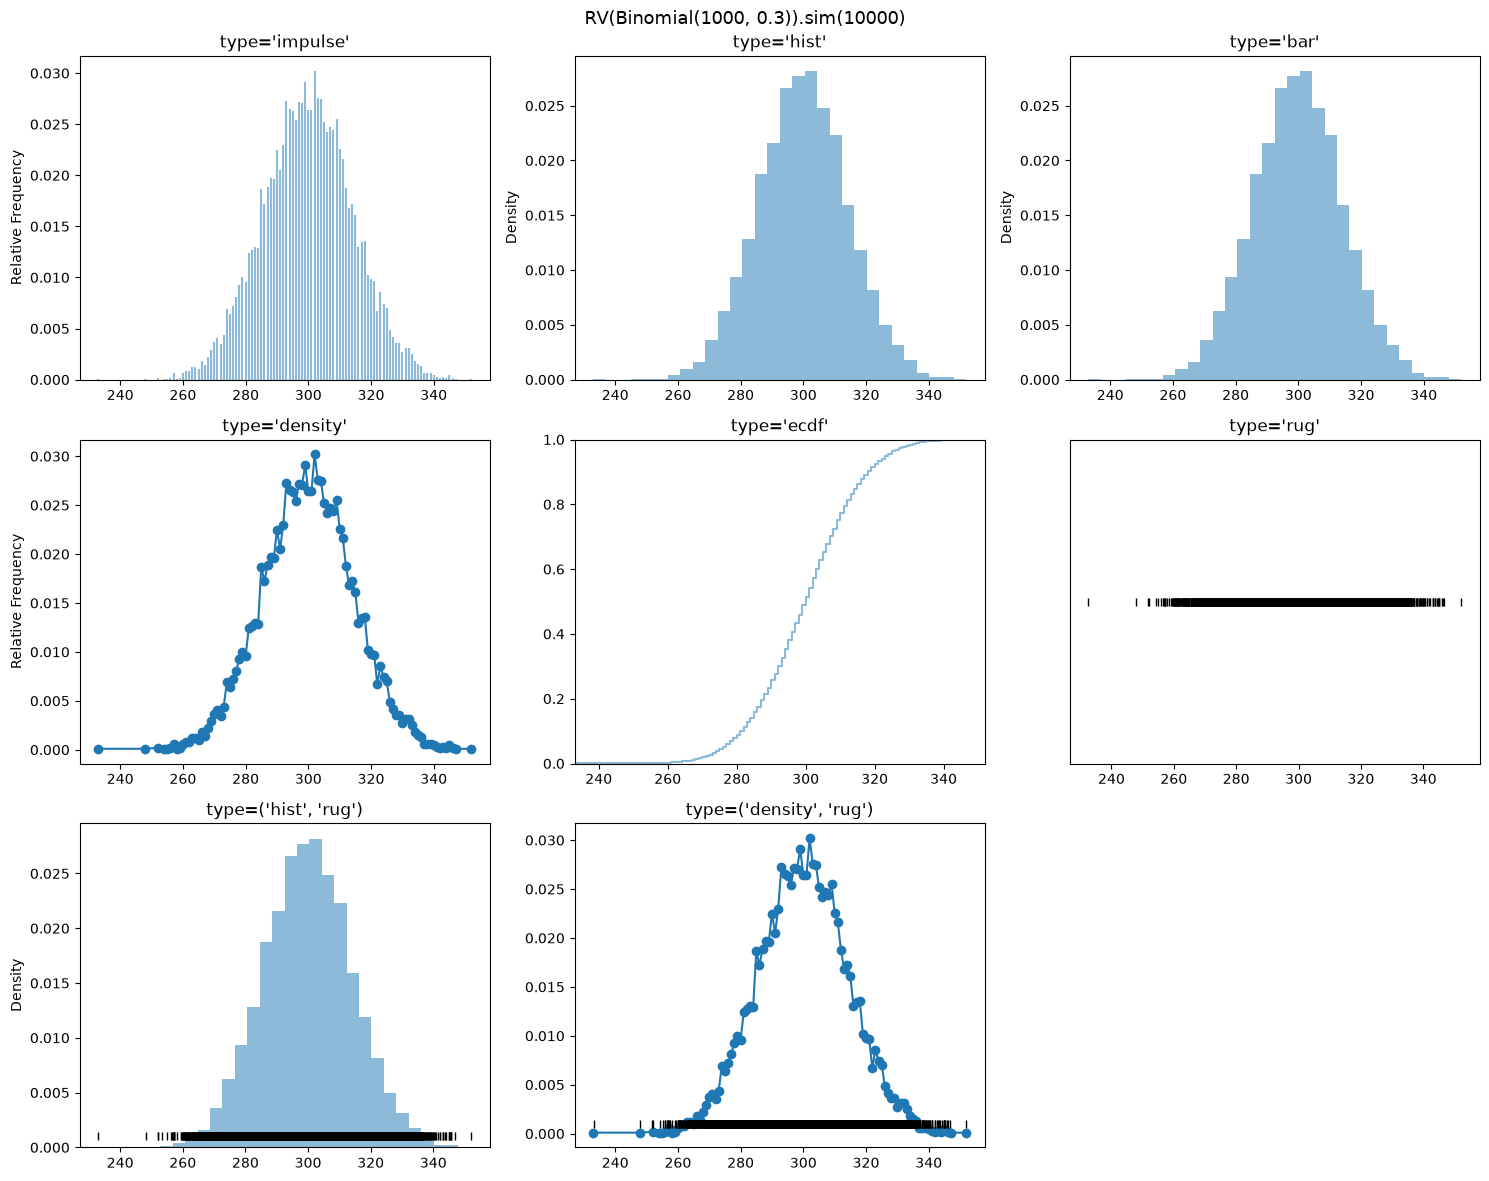

In [ ]:
show_types(RV(Binomial(1000, 0.3)).sim(10000), ONE_D_TYPES,
           "RV(Binomial(1000, 0.3)).sim(10000)")

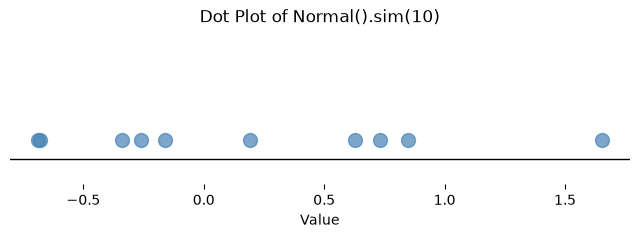

In [ ]:
from symbulate import *
import matplotlib.pyplot as plt

x = Normal().sim(10)

fig, ax = plt.subplots(figsize=(8, 2))

# the "scale" - a horizontal line the dots sit above
ax.axhline(0, color='black', linewidth=1)

# dots sitting just above the scale
dot_height = 0.15
ax.plot(x, [dot_height] * len(x), 'o', markersize=10, color='steelblue', alpha=0.7, zorder=3)

# clean up so it looks like a number line, not a chart
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(-0.2, 1)
ax.set_xlabel('Value')
ax.set_title('Dot Plot of Normal().sim(10)')

plt.show()


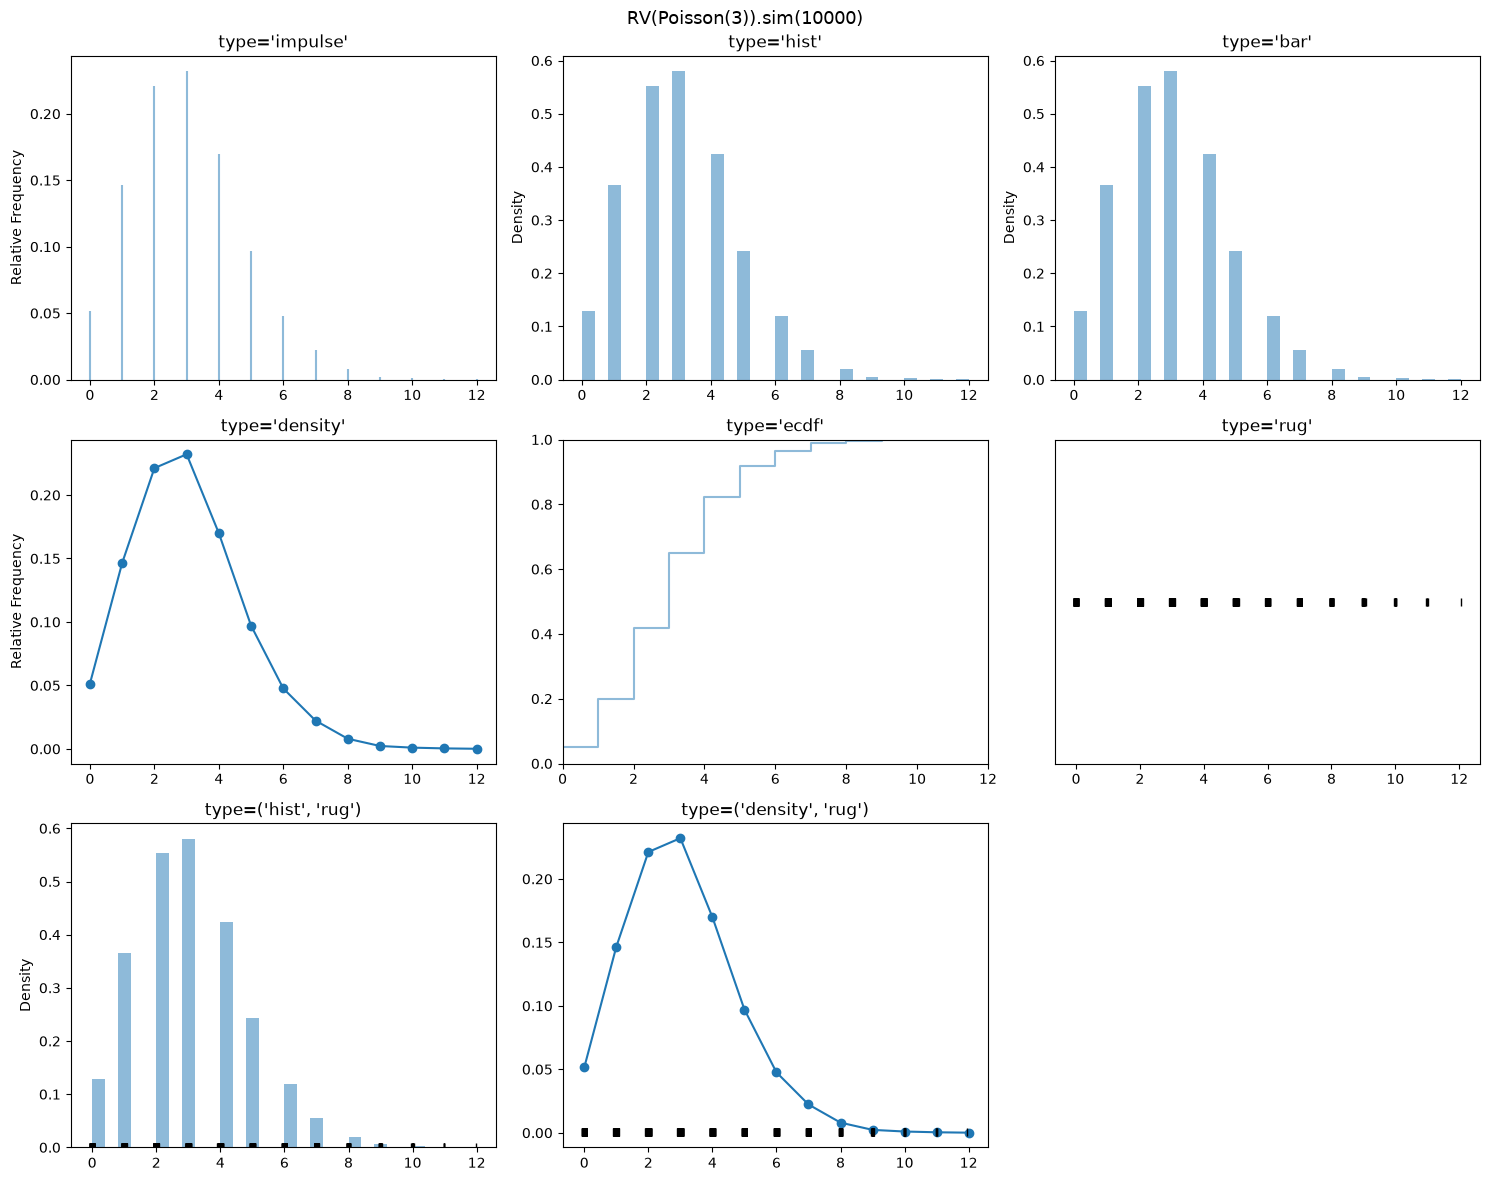

In [ ]:
show_types(RV(Poisson(3)).sim(10000), ONE_D_TYPES,
           "RV(Poisson(3)).sim(10000)")

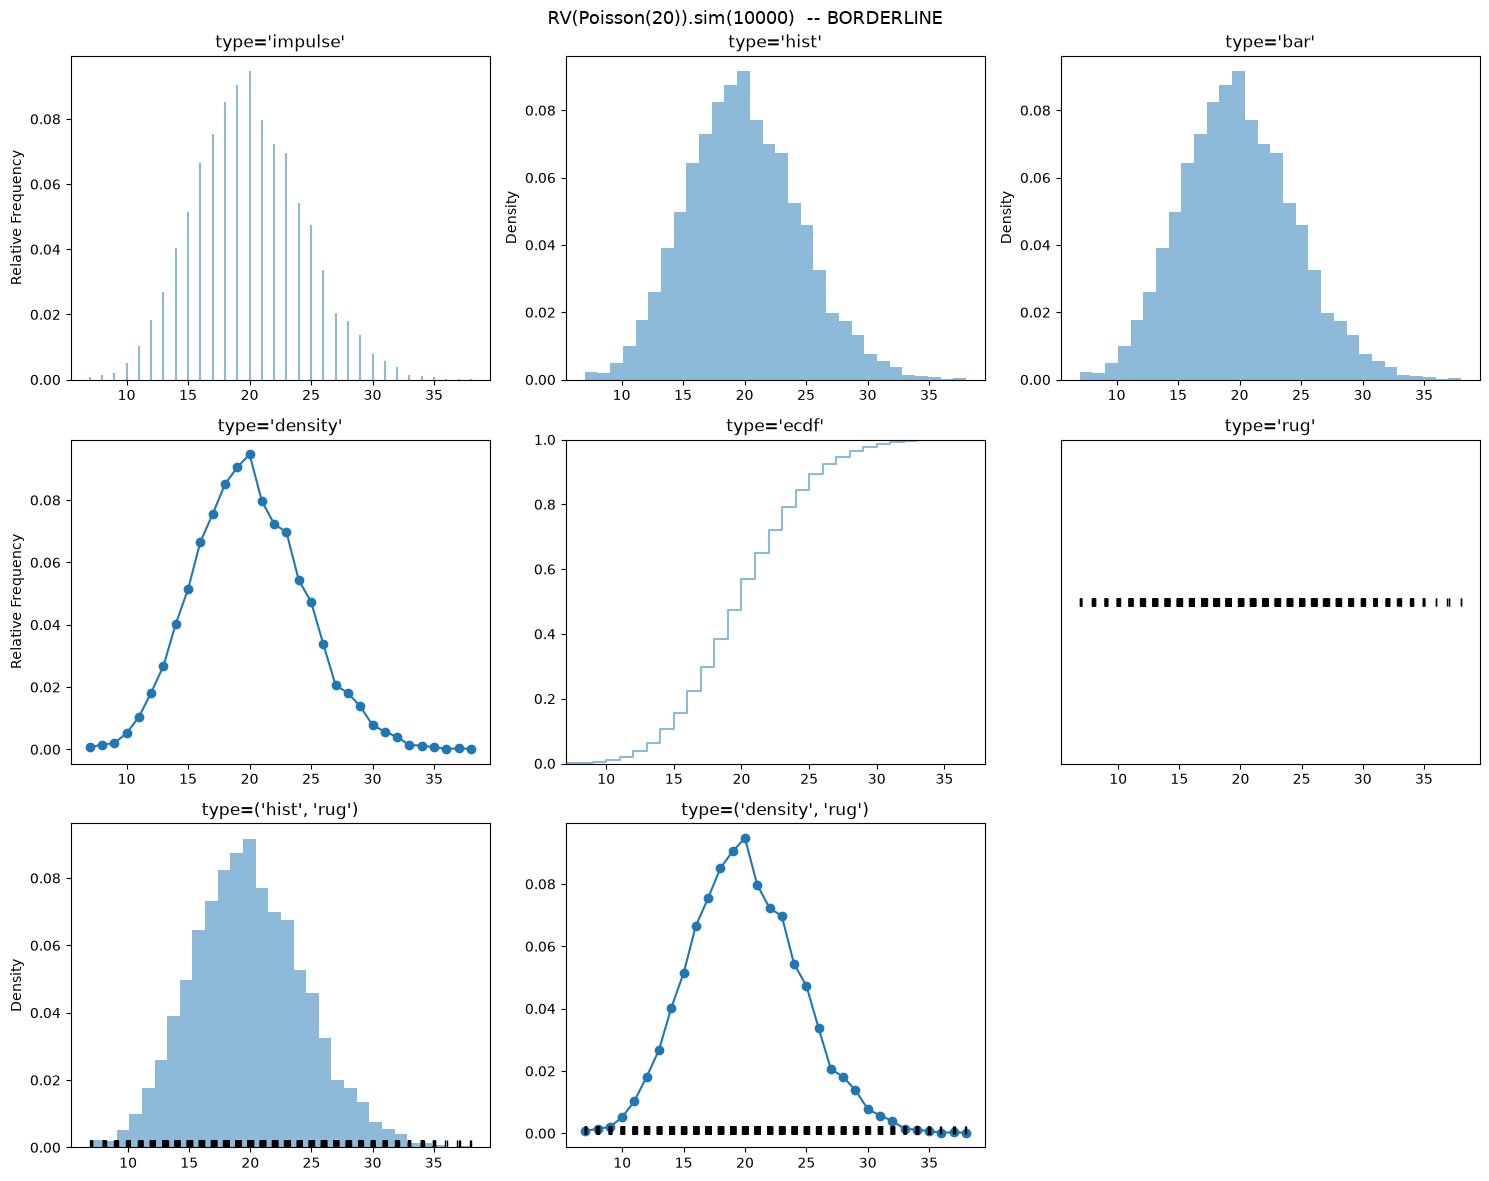

In [ ]:
# Borderline case: Poisson(20) has a wide-ish discrete support (mean 20).
# Watch for whether impulse still reads cleanly or starts to look like a
# jagged histogram once the support gets wide relative to n.
show_types(RV(Poisson(20)).sim(10000), ONE_D_TYPES,
           "RV(Poisson(20)).sim(10000)  -- BORDERLINE")

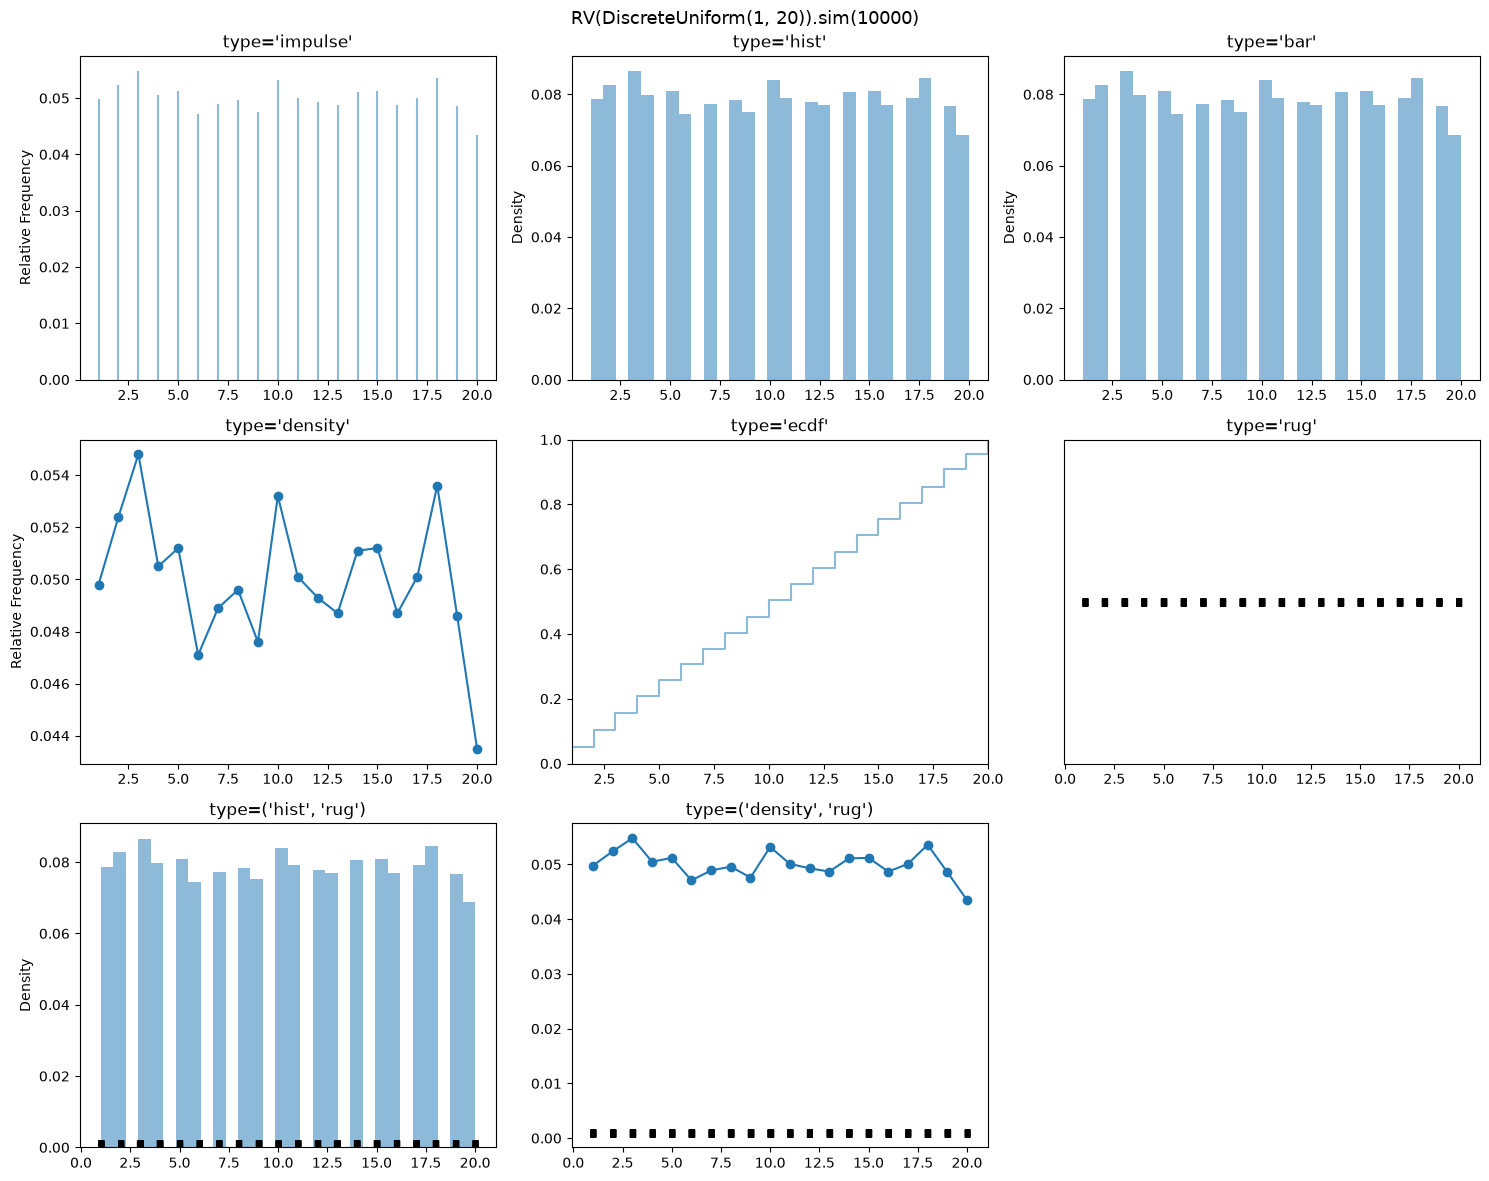

In [ ]:
show_types(RV(DiscreteUniform(1, 20)).sim(10000), ONE_D_TYPES,
           "RV(DiscreteUniform(1, 20)).sim(10000)")

_Your notes -- best default / reasonable alternatives for 1D discrete-ish, large n:_\n\n- 

## 1D continuous-ish, small n (n=10)

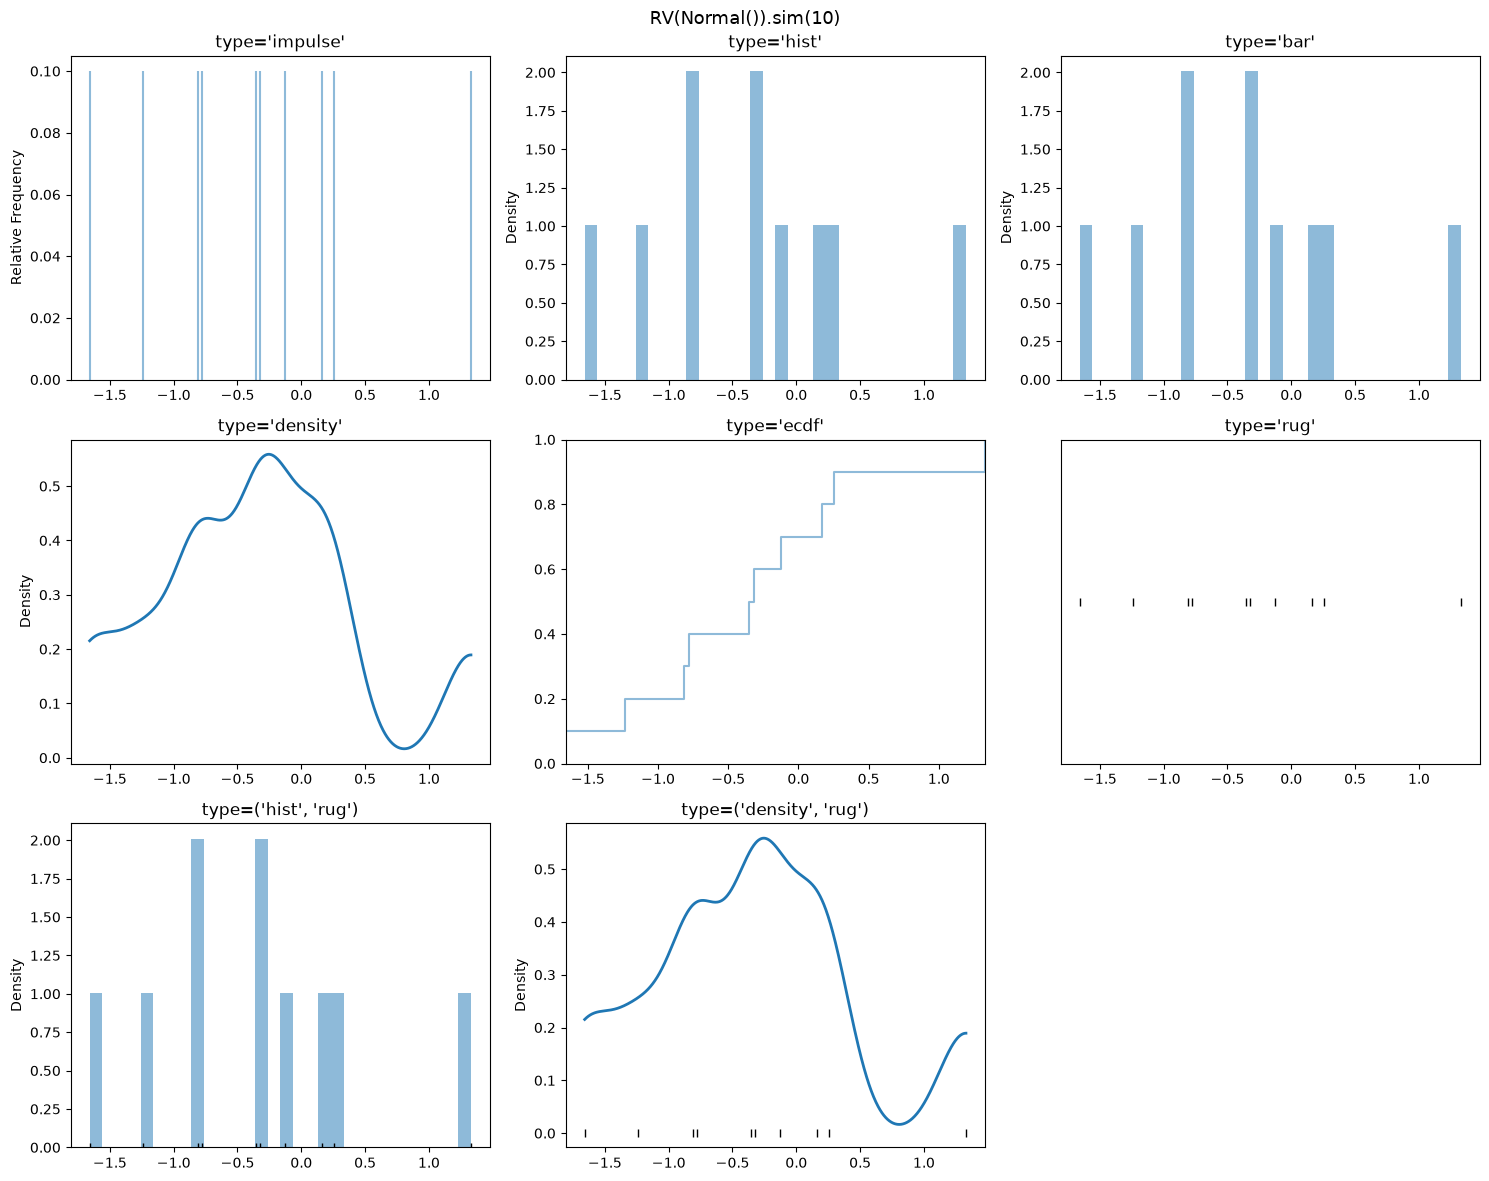

In [ ]:
show_types(RV(Normal()).sim(10), ONE_D_TYPES,
           "RV(Normal()).sim(10)")

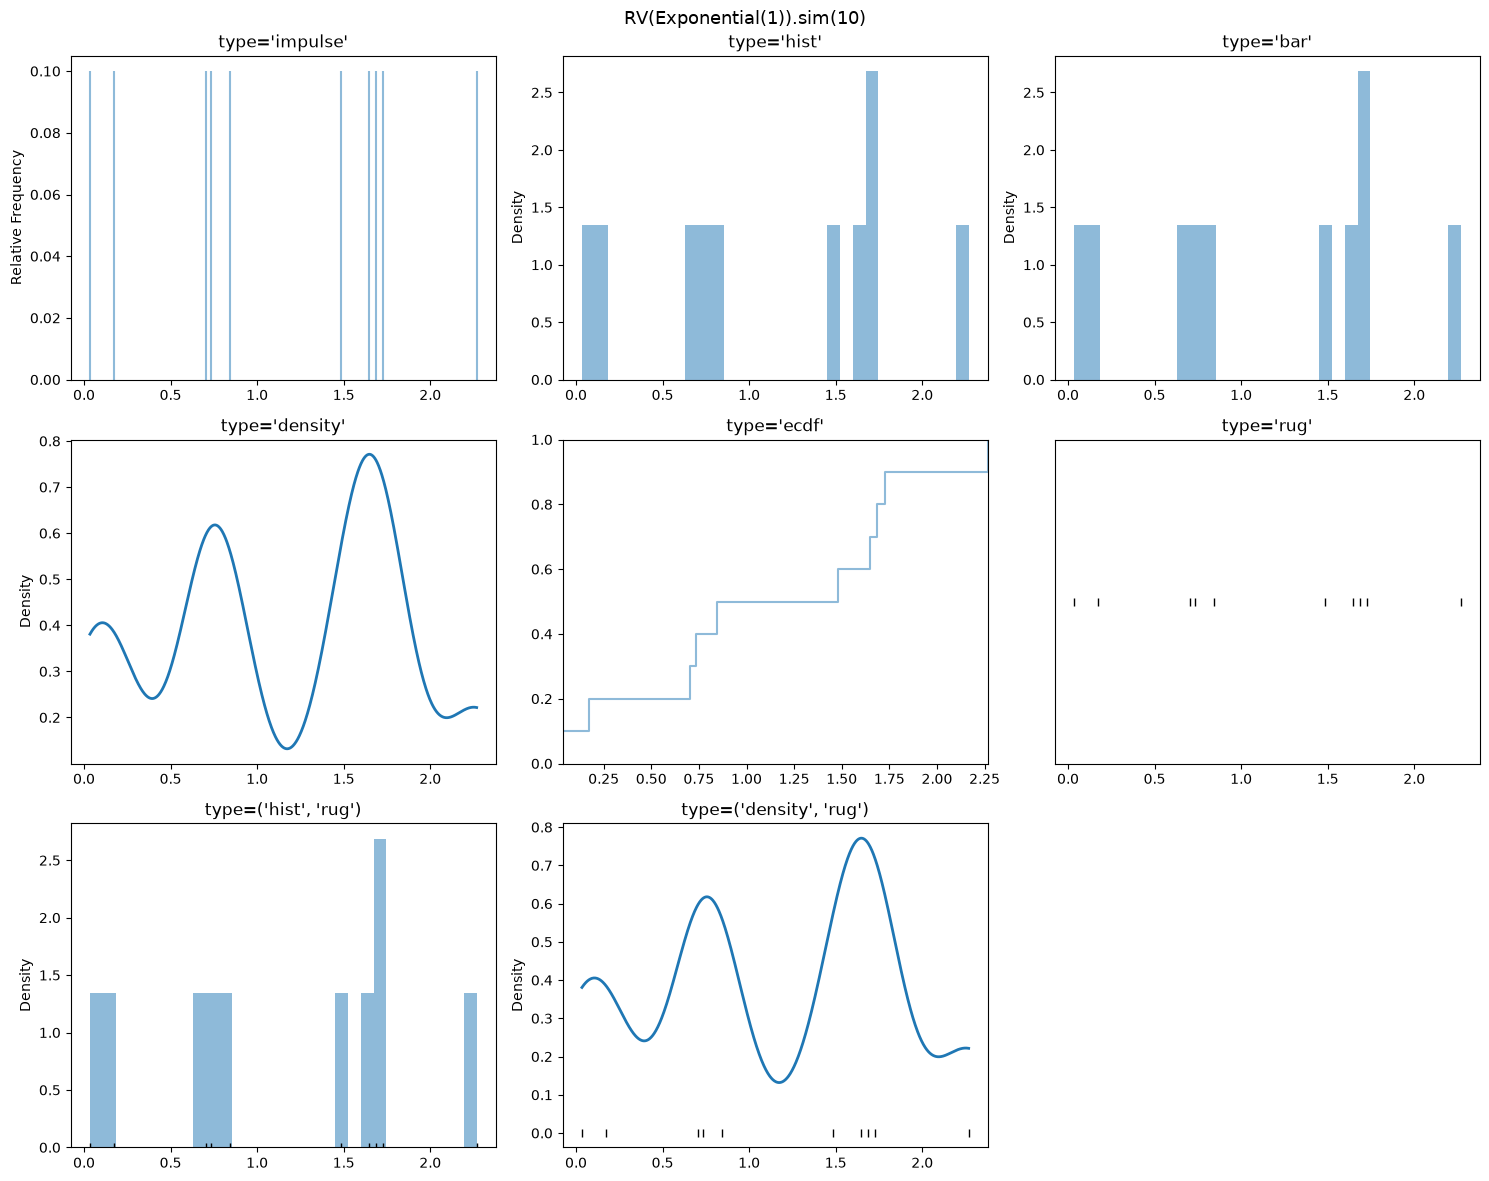

In [ ]:
show_types(RV(Exponential(1)).sim(10), ONE_D_TYPES,
           "RV(Exponential(1)).sim(10)")

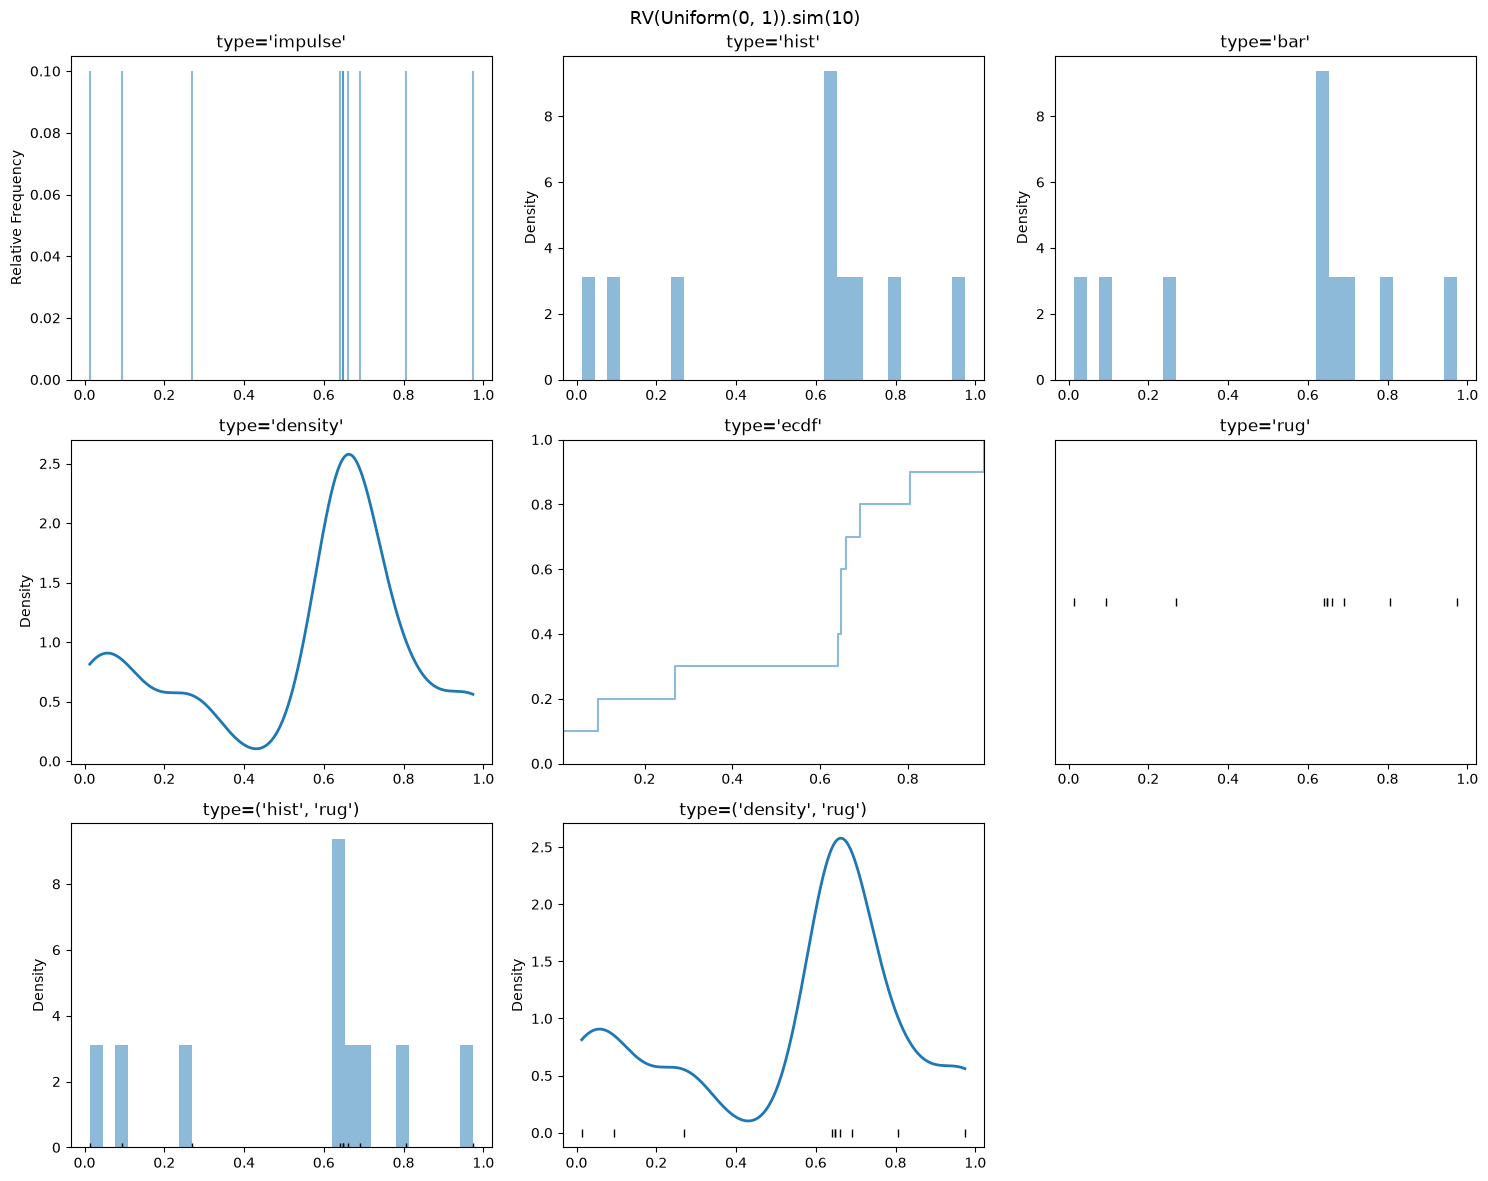

In [ ]:
show_types(RV(Uniform(0, 1)).sim(10), ONE_D_TYPES,
           "RV(Uniform(0, 1)).sim(10)")

_Your notes -- best default / reasonable alternatives for 1D continuous-ish, small n:_\n\n- 

## 1D continuous-ish, large n (n=10000)

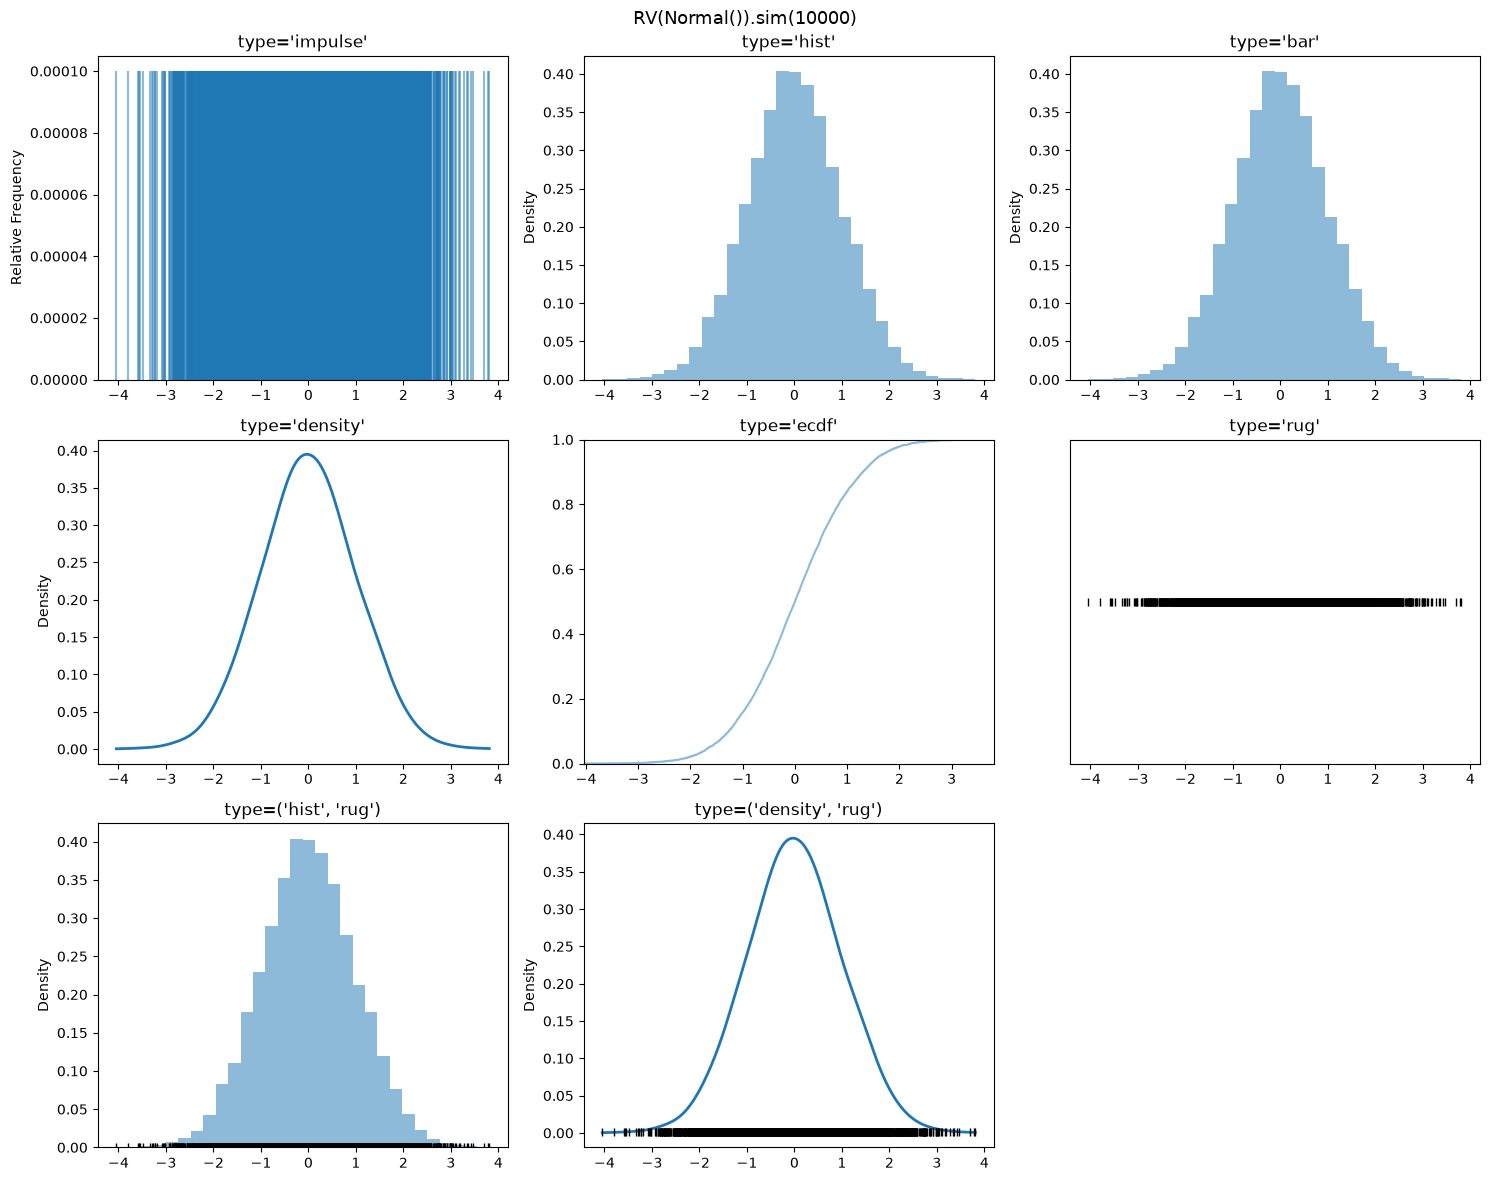

In [ ]:
show_types(RV(Normal()).sim(10000), ONE_D_TYPES,
           "RV(Normal()).sim(10000)")

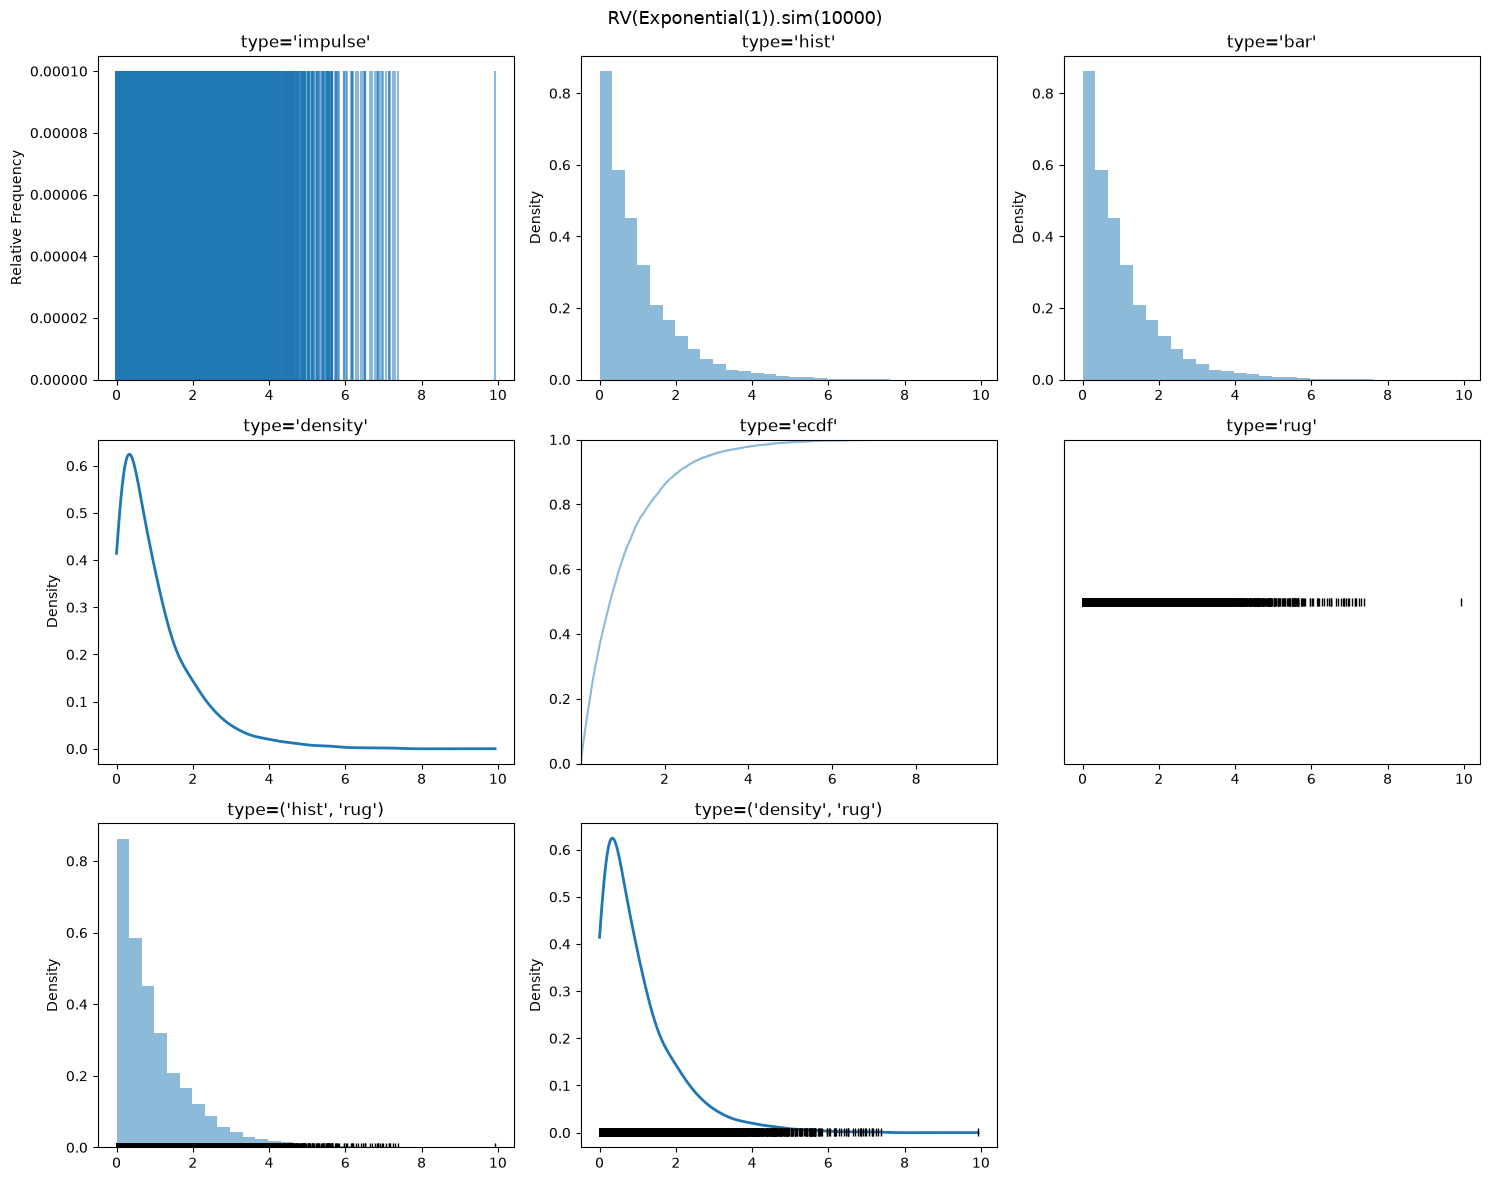

In [ ]:
show_types(RV(Exponential(1)).sim(10000), ONE_D_TYPES,
           "RV(Exponential(1)).sim(10000)")

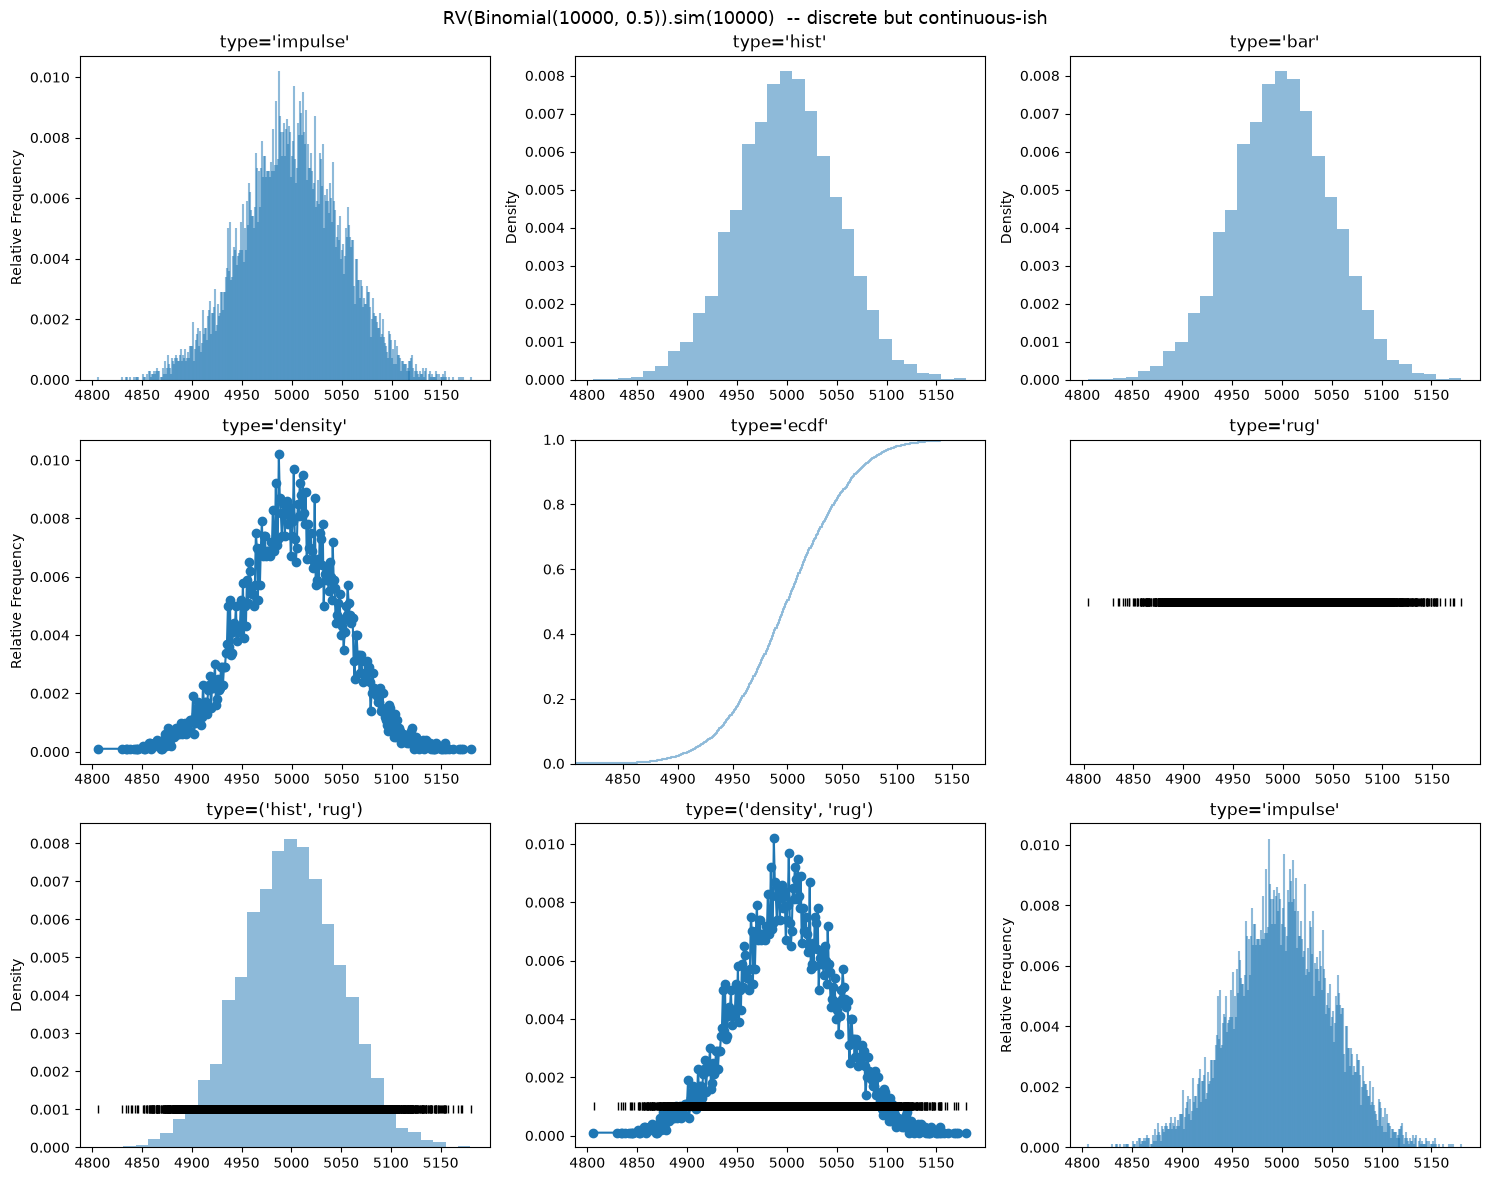

In [ ]:
# Discrete but continuous-ish: Binomial(10000, 0.5) has ~10000 possible
# values concentrated in a narrow-relative-to-range band, so it *behaves*
# like a continuous variable even though it is technically discrete.
show_types(RV(Binomial(10000, 0.5)).sim(10000), ONE_D_TYPES + ['impulse'],
           "RV(Binomial(10000, 0.5)).sim(10000)  -- discrete but continuous-ish")

_Your notes -- best default / reasonable alternatives for 1D continuous-ish, large n:_\n\n- 

## 2D discrete x discrete

Note: `mosaic` only works when **both** variables are discrete -- for any other
combination it raises `Mosaic plots can only be made for 2 discrete random
variables.` (shown inline below where relevant).

--- RV(Binomial(5,0.3) * Binomial(5,0.3)).sim(10000) ---


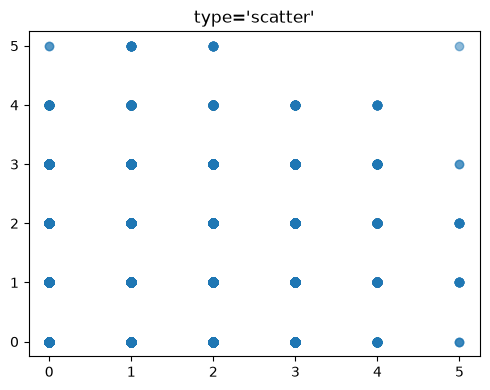

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


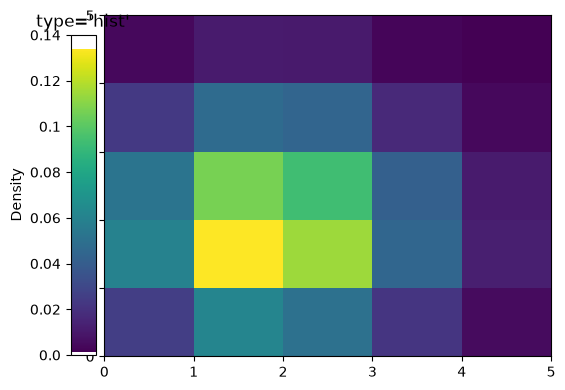

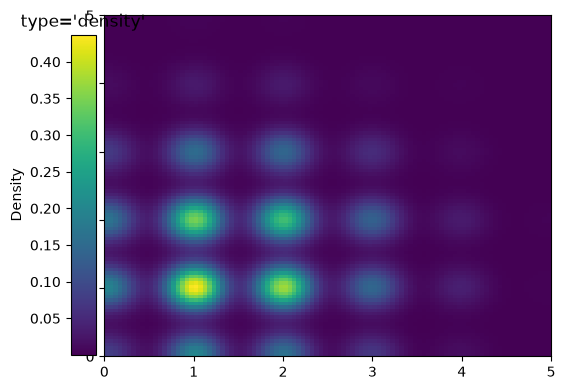

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


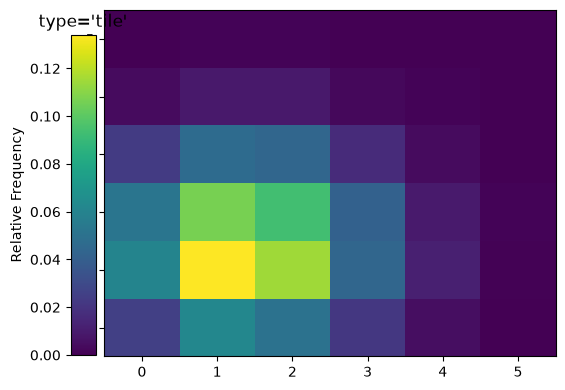

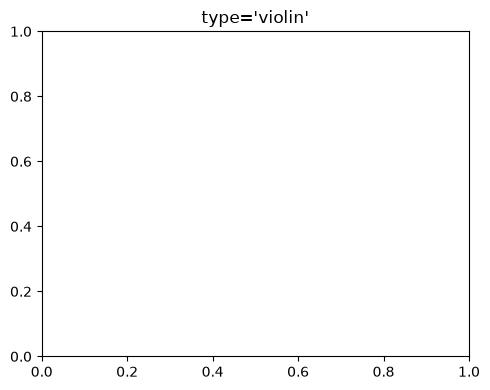

<Figure size 500x400 with 0 Axes>

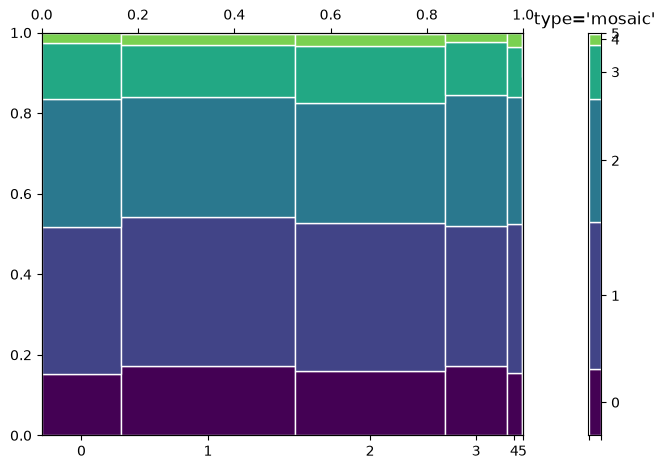

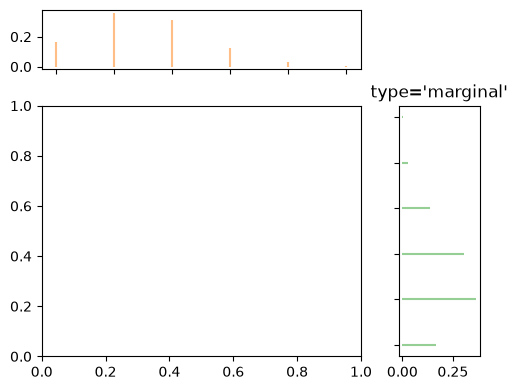

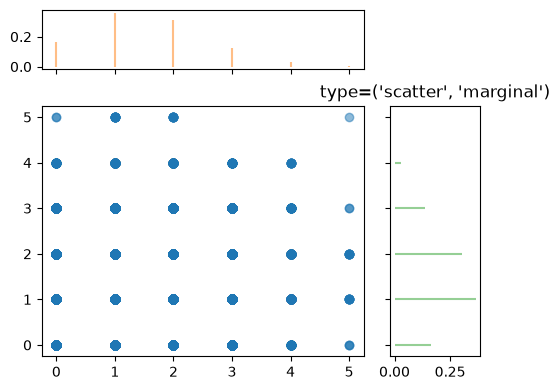

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


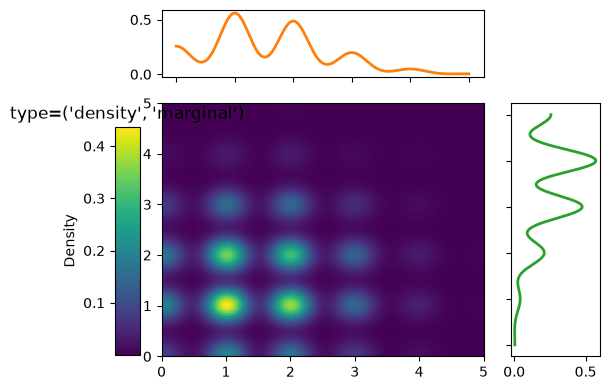

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


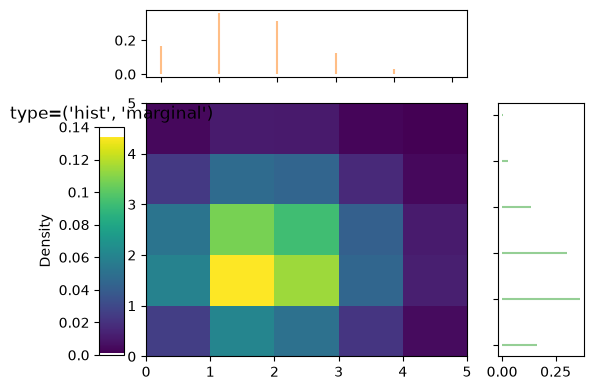

In [ ]:
show_types_2d(RV(Binomial(5, 0.3) * Binomial(5, 0.3)).sim(10000), TWO_D_TYPES,
           "RV(Binomial(5,0.3) * Binomial(5,0.3)).sim(10000)")

--- RV(Poisson(3) * Poisson(2)).sim(10000) ---


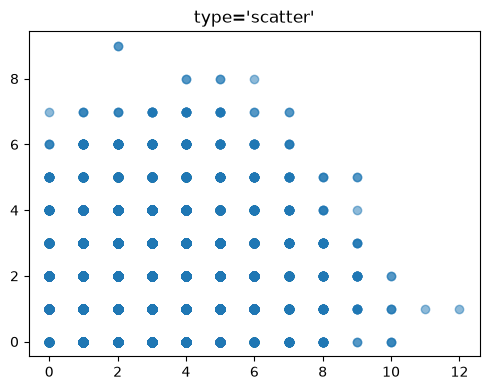

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


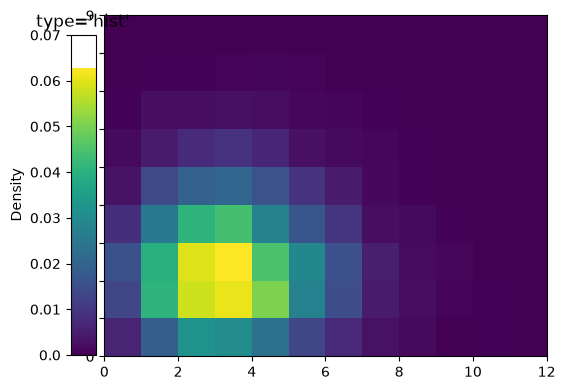

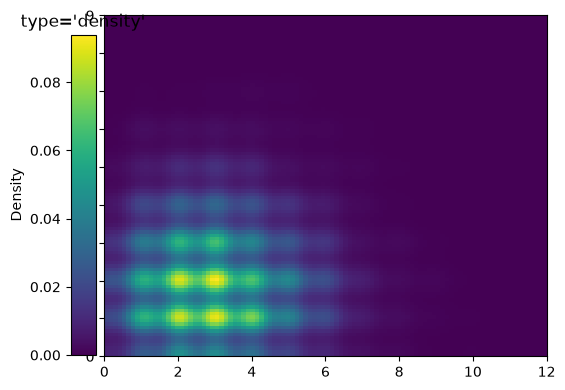

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


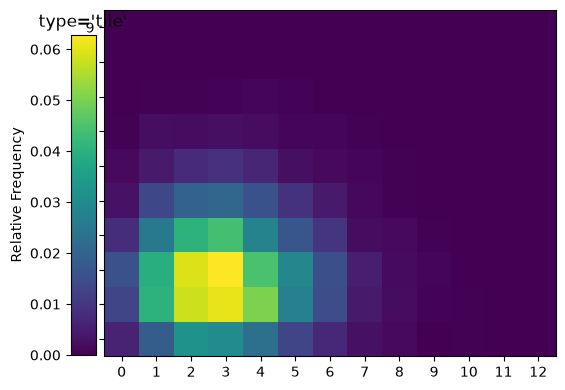

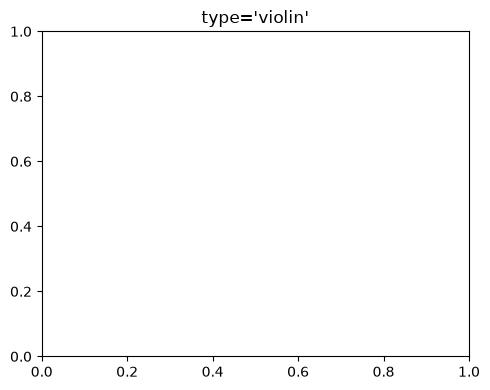

<Figure size 500x400 with 0 Axes>

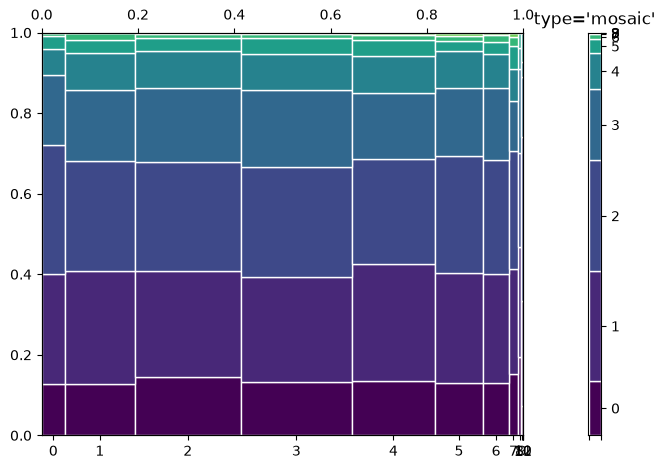

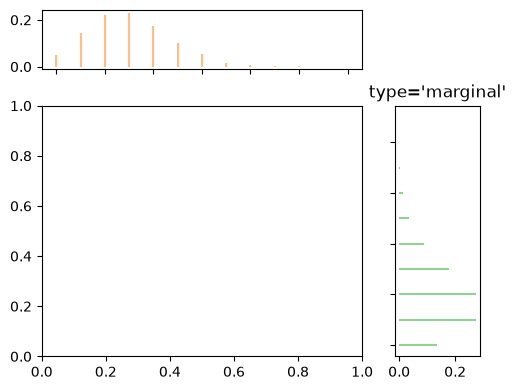

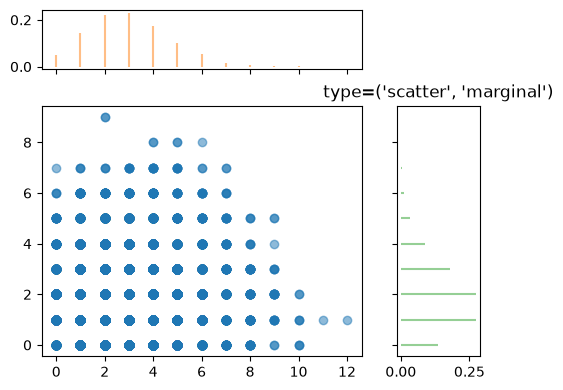

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


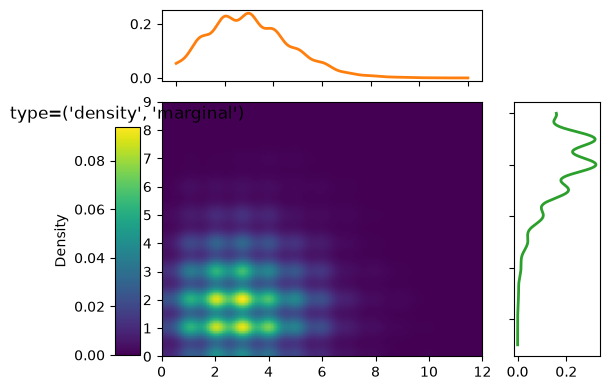

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


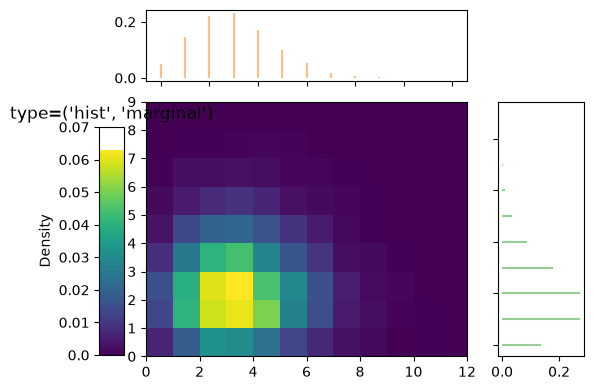

In [ ]:
show_types_2d(RV(Poisson(3) * Poisson(2)).sim(10000), TWO_D_TYPES,
           "RV(Poisson(3) * Poisson(2)).sim(10000)")

--- RV(Binomial(5,0.3) * Binomial(5,0.3)).sim(50) ---


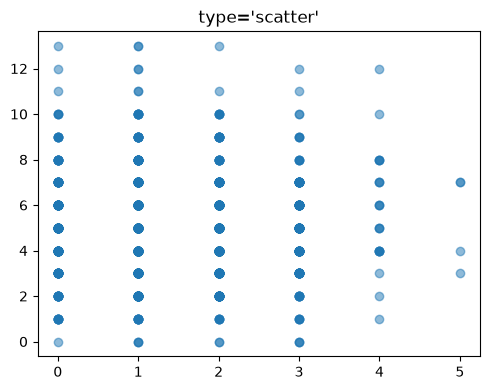

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


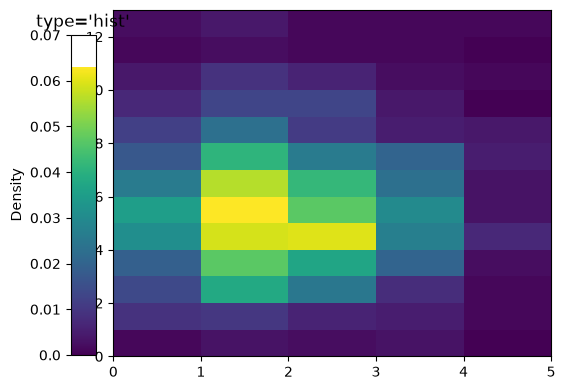

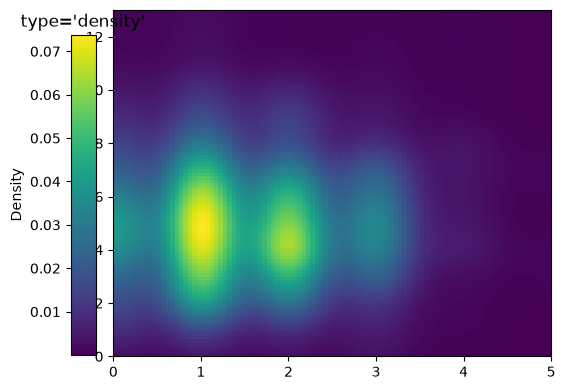

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


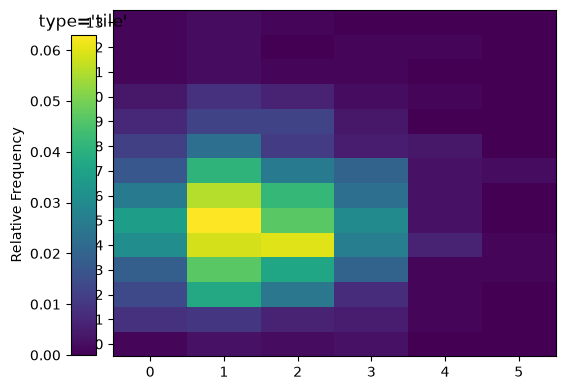

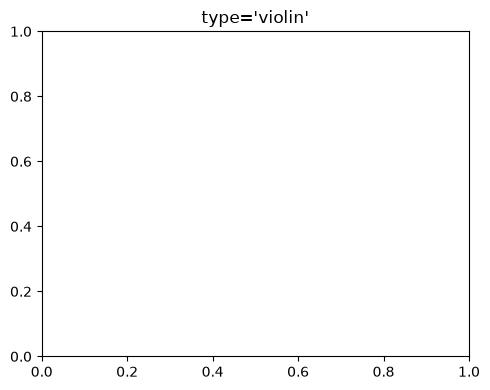

<Figure size 500x400 with 0 Axes>

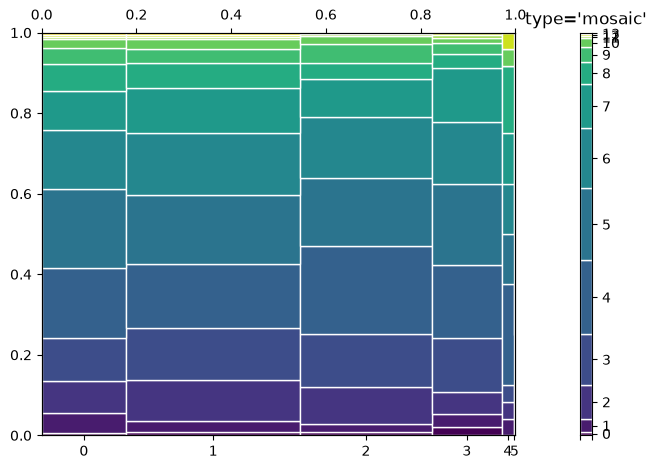

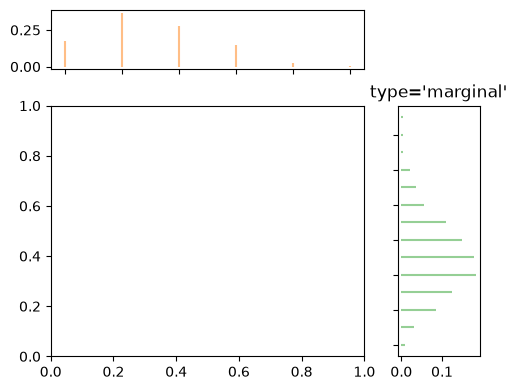

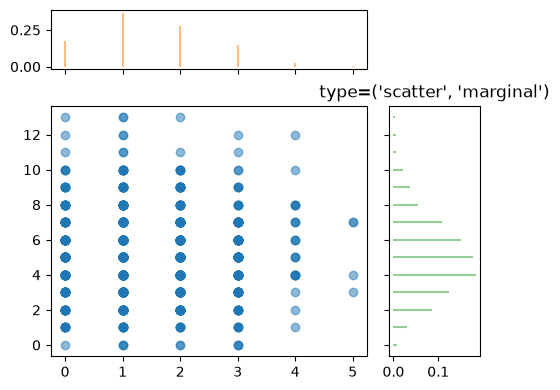

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


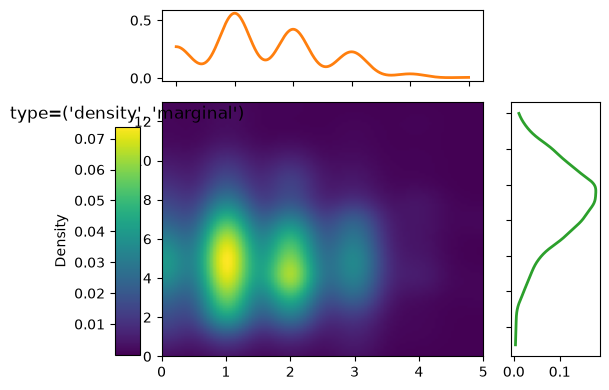

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


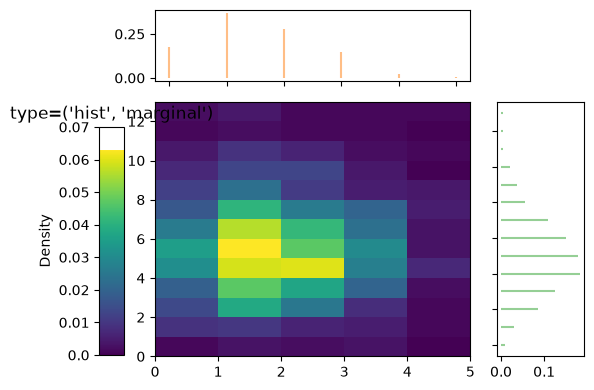

In [ ]:
show_types_2d(RV(Binomial(5, 0.3) * Poisson(5)).sim(1000), TWO_D_TYPES,
           "RV(Binomial(5,0.3) * Binomial(5,0.3)).sim(50)")

_Your notes -- best default / reasonable alternatives for 2D discrete x discrete:_\n\n- 

## 2D continuous x continuous

--- RV(Normal() * Normal()).sim(20) ---


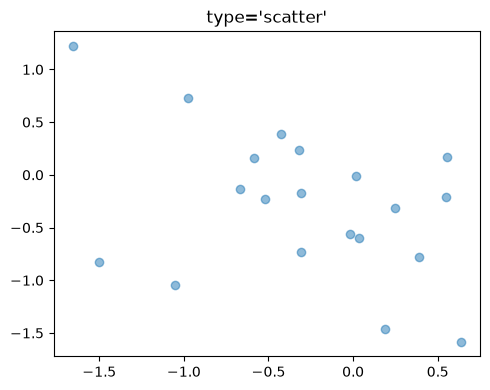

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


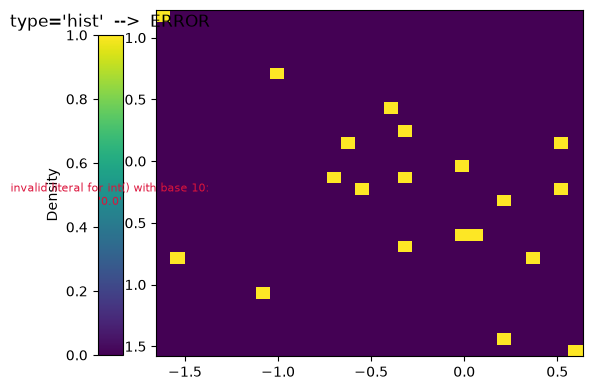

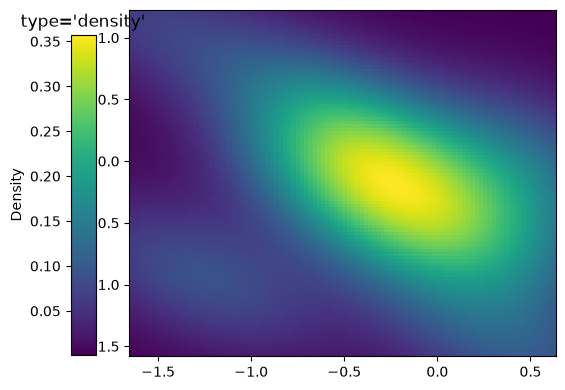

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


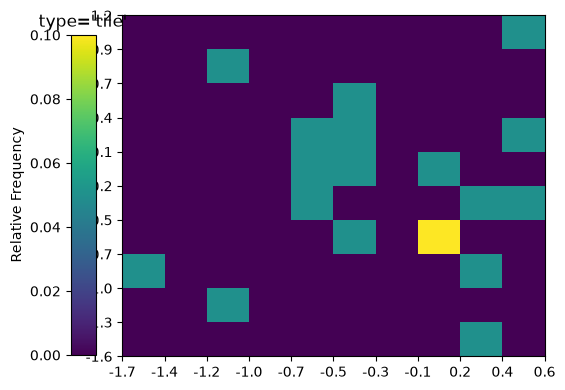

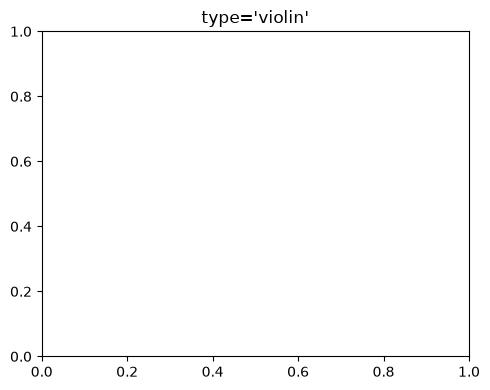

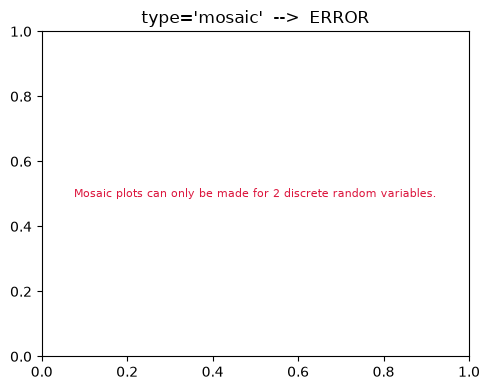

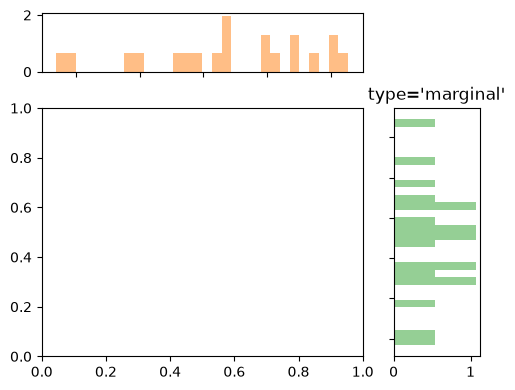

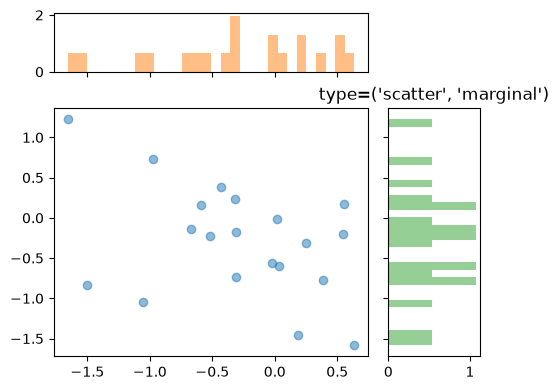

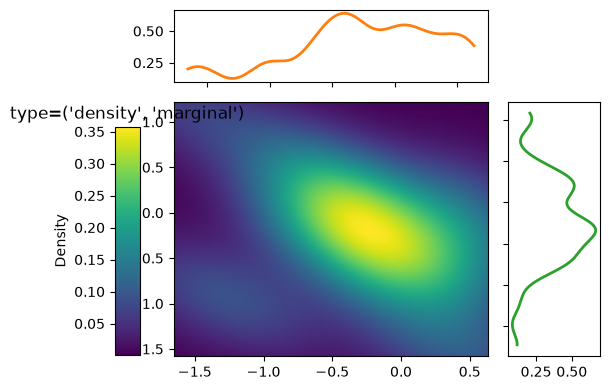

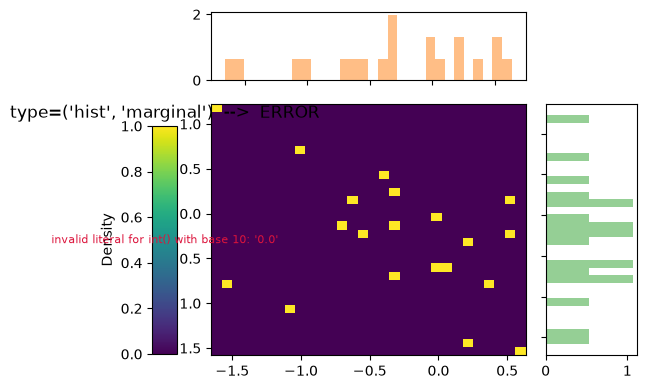

In [ ]:
show_types_2d(RV(Normal() * Normal()).sim(20), TWO_D_TYPES,
           "RV(Normal() * Normal()).sim(20)")

--- RV(Normal() * Normal()).sim(10000) ---


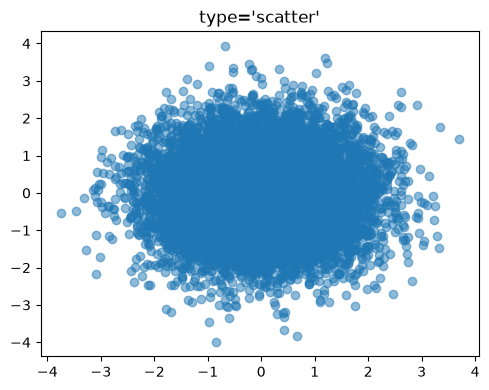

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


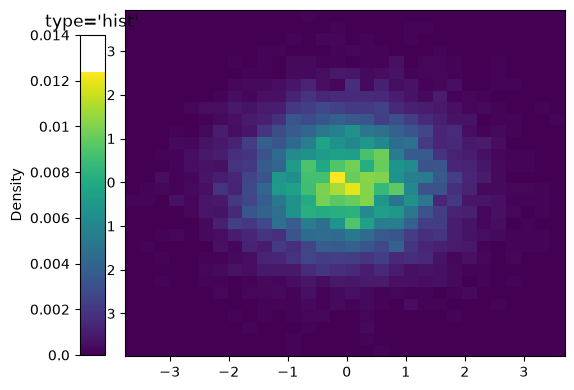

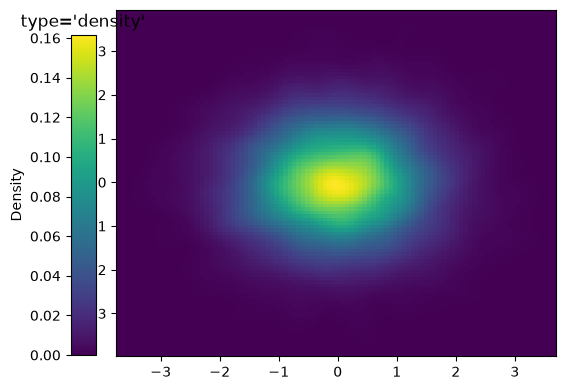

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


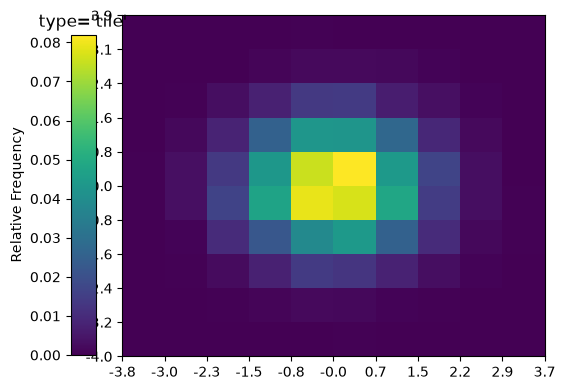

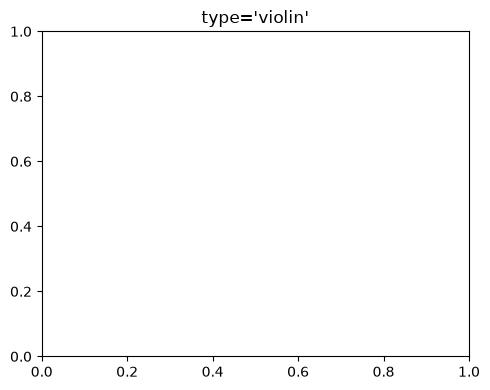

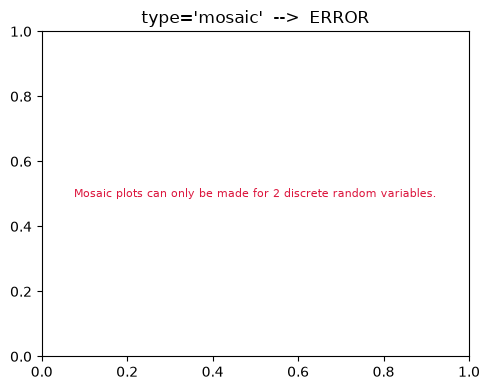

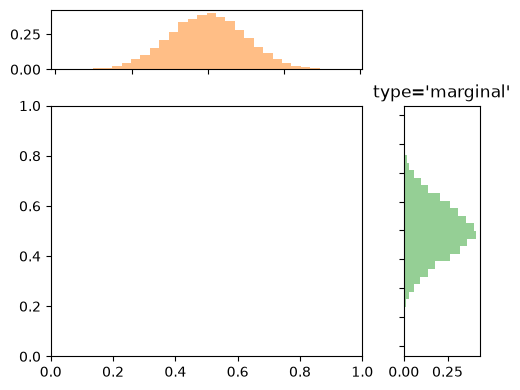

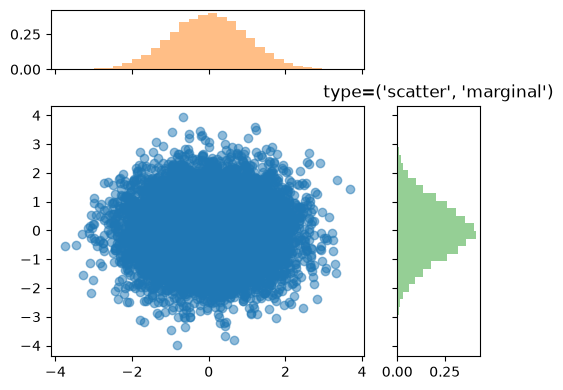

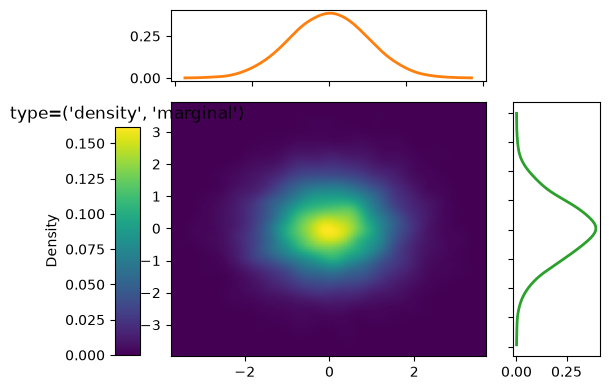

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


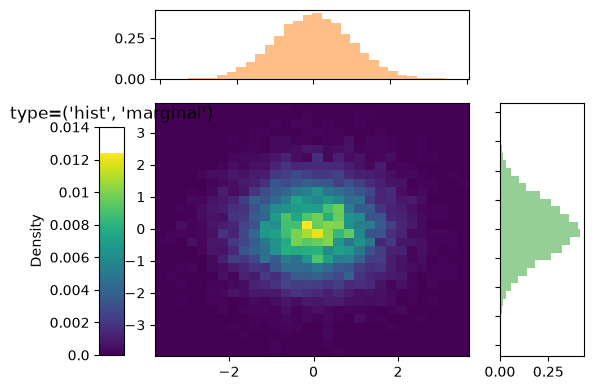

In [ ]:
show_types_2d(RV(Normal() * Normal()).sim(10000), TWO_D_TYPES,
           "RV(Normal() * Normal()).sim(10000)")

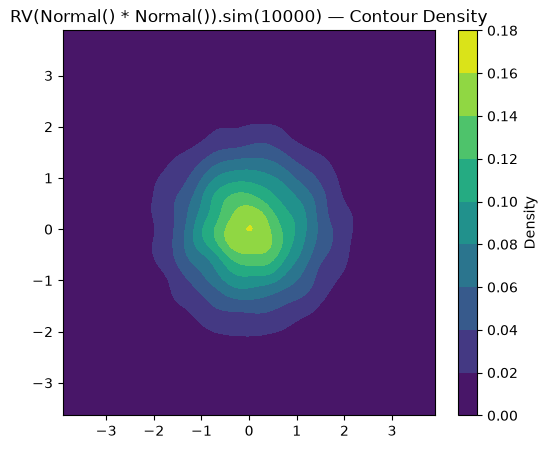

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from symbulate import *

sim = RV(Normal() * Normal()).sim(10000)
sim._set_array()
x, y = sim.array[:, 0], sim.array[:, 1]

# estimate the 2D density
xy = np.vstack([x, y])
density = gaussian_kde(xy)
xg, yg = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),
    np.linspace(y.min(), y.max(), 100)
)
zg = density(np.vstack([xg.ravel(), yg.ravel()])).reshape(xg.shape)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(xg, yg, zg, levels=8, cmap='viridis')
fig.colorbar(cs, label='Density')
ax.set_title("RV(Normal() * Normal()).sim(10000) — Contour Density")
plt.show()


--- RV(Normal() * Normal()).sim(50) ---


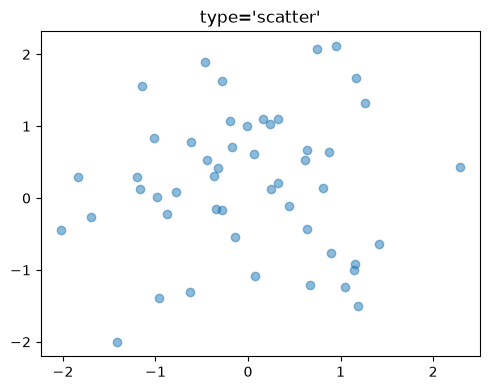

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


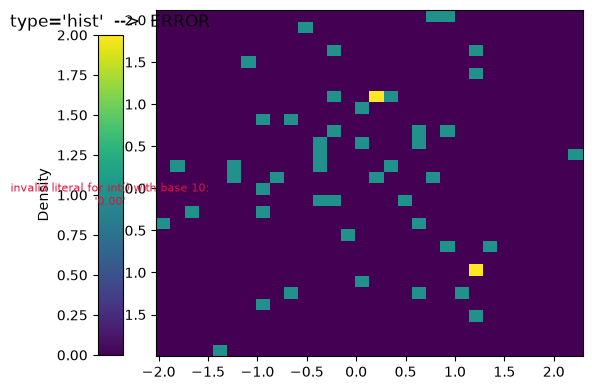

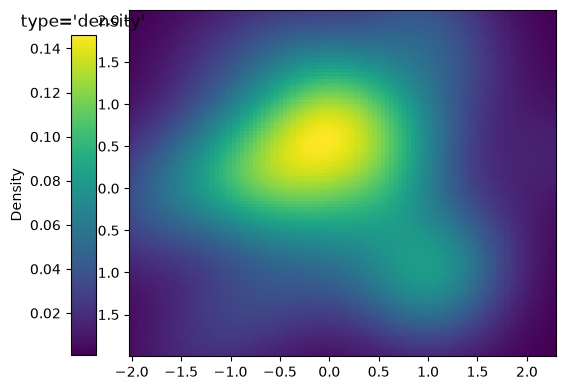

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


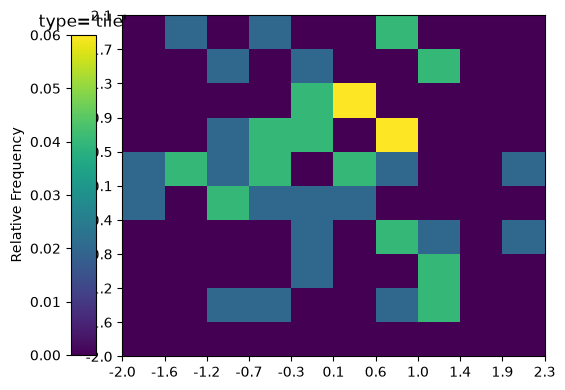

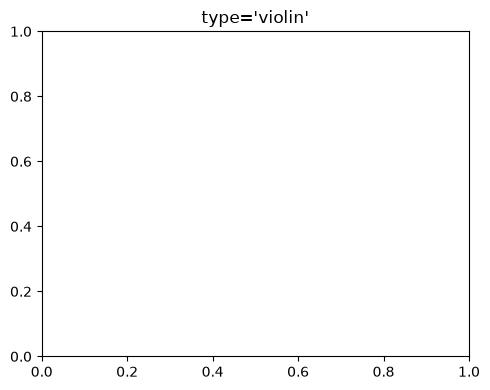

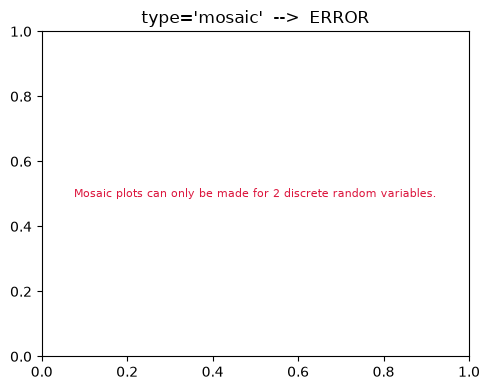

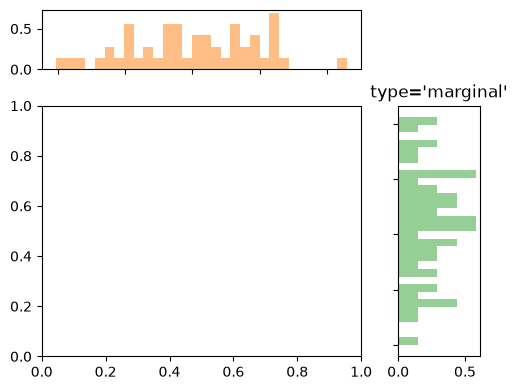

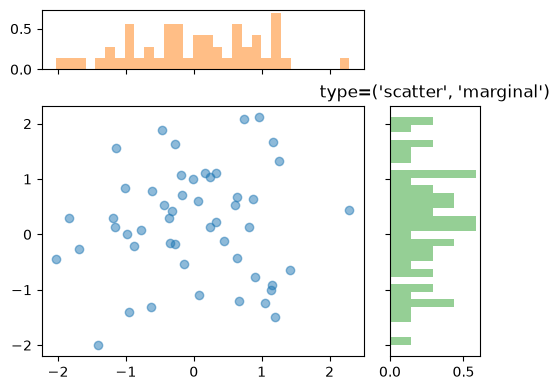

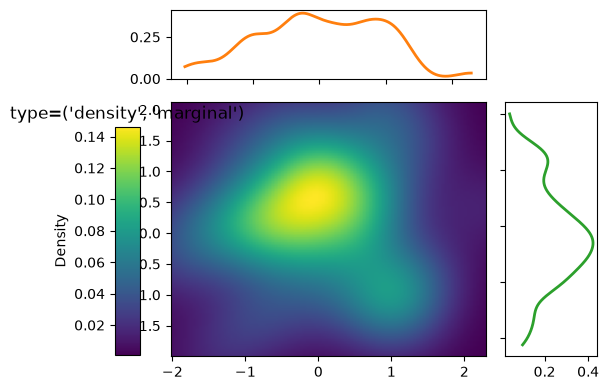

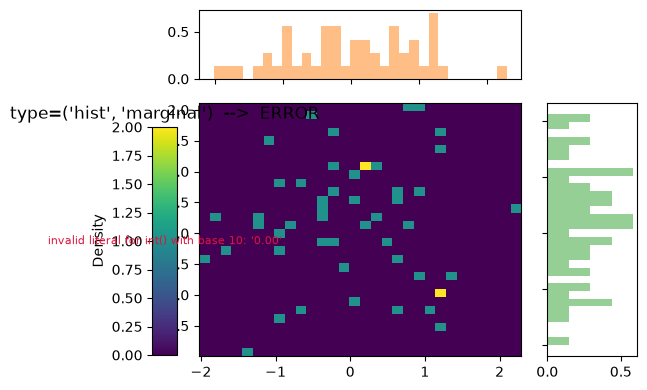

In [ ]:
show_types_2d(RV(Normal() * Normal()).sim(50), TWO_D_TYPES,
           "RV(Normal() * Normal()).sim(50)")

--- RV(BivariateNormal()).sim(10000) ---


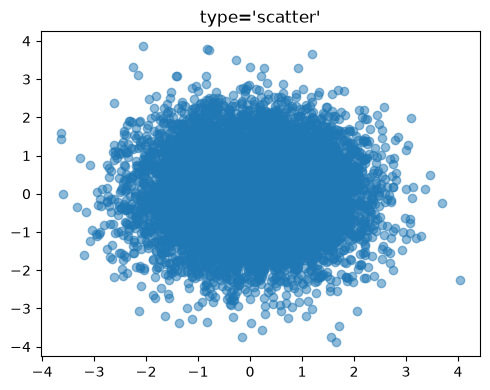

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


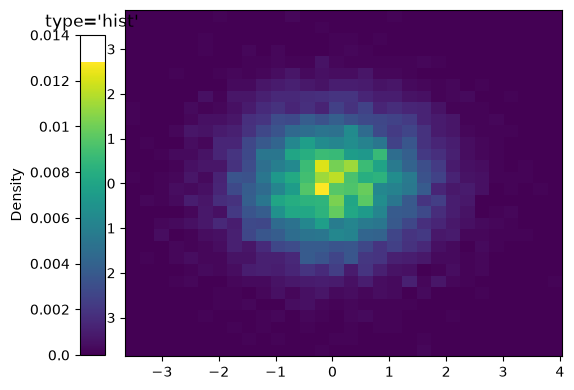

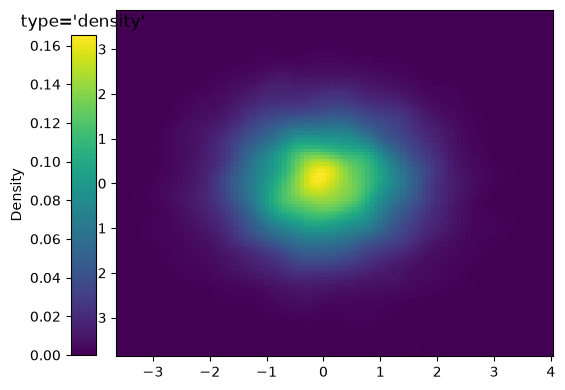

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


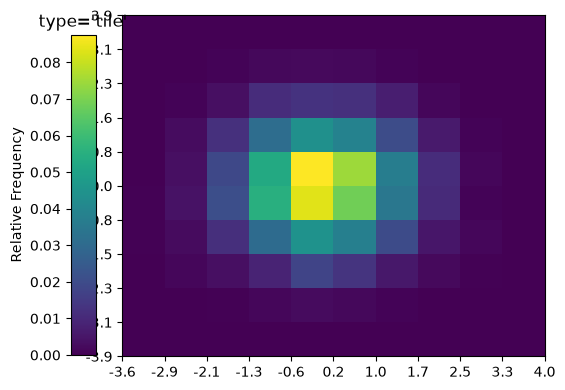

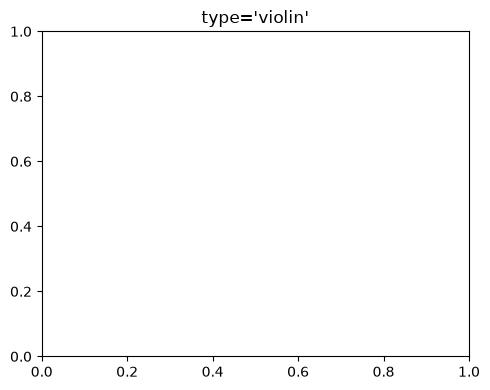

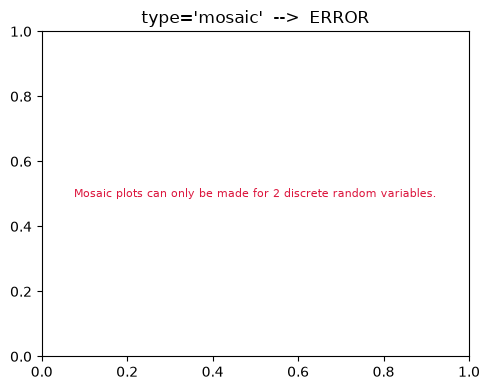

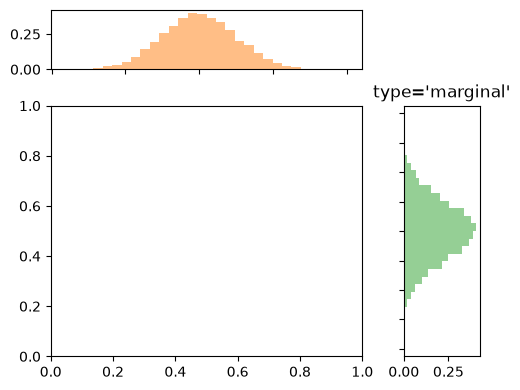

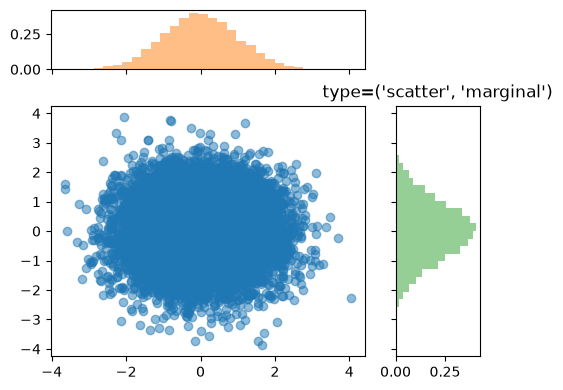

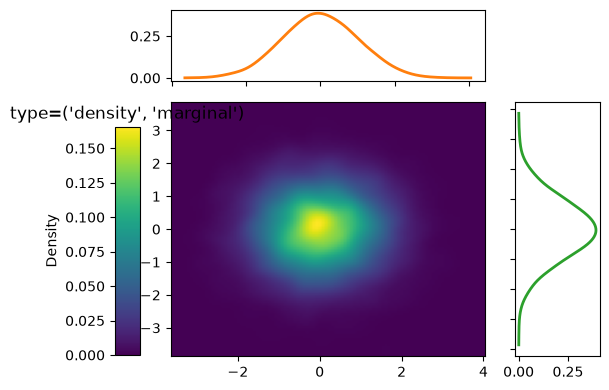

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


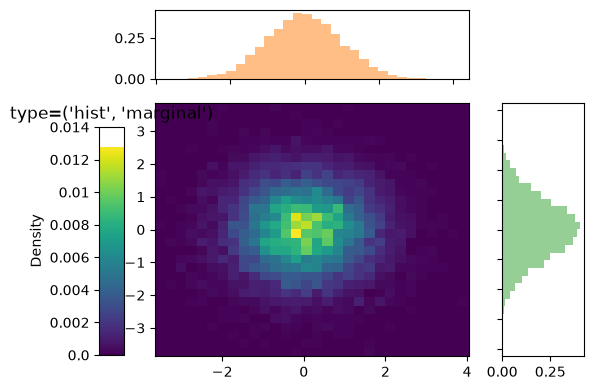

In [ ]:
show_types_2d(RV(BivariateNormal()).sim(10000), TWO_D_TYPES,
           "RV(BivariateNormal()).sim(10000)")

_Your notes -- best default / reasonable alternatives for 2D continuous x continuous:_\n\n- 

## 2D discrete x continuous

Note: `hist` (2D histogram) has a real bug at small n for mixed discrete/continuous
data -- `RV(Poisson(3) * Normal()).sim(50).plot(type='hist')` raises
`invalid literal for int() with base 10: '0.00'`. That's not a notebook artifact;
it reproduces directly against this fork. Worth flagging as a known issue
regardless of what `classify_data` ends up defaulting to.

--- RV(Poisson(3) * Normal()).sim(20) ---


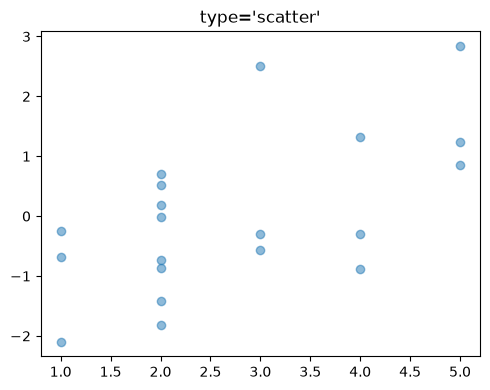

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


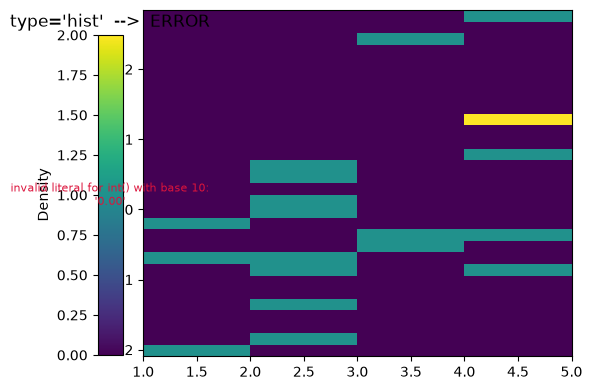

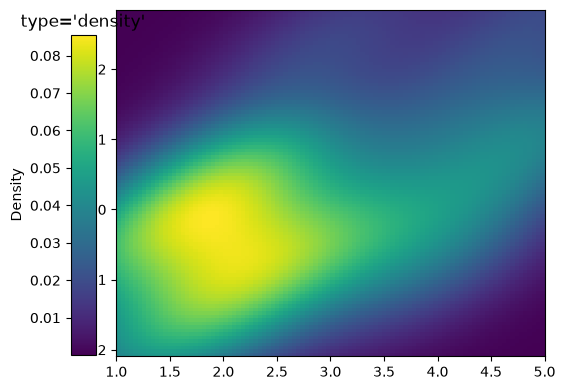

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


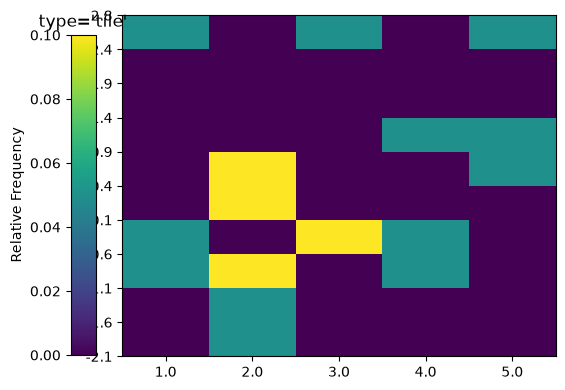

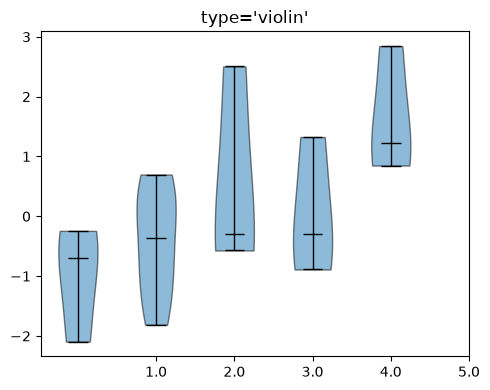

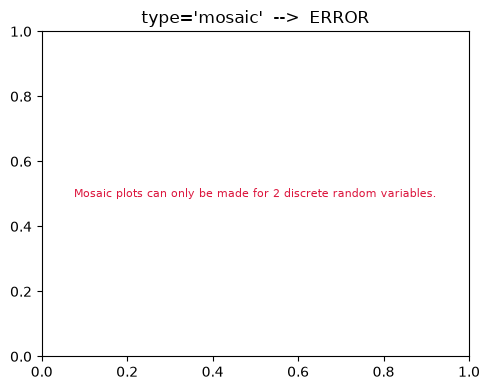

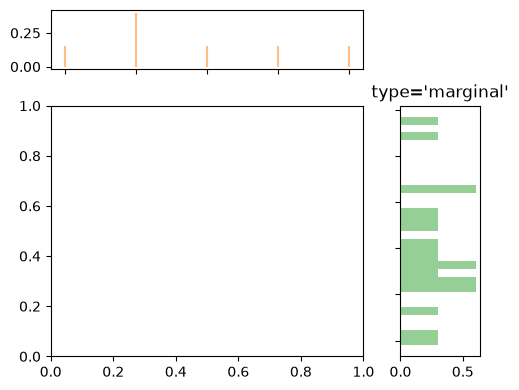

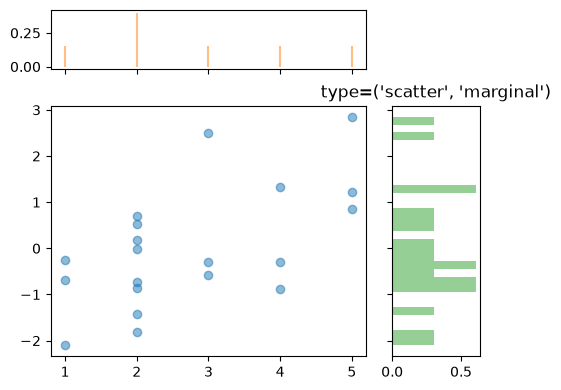

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


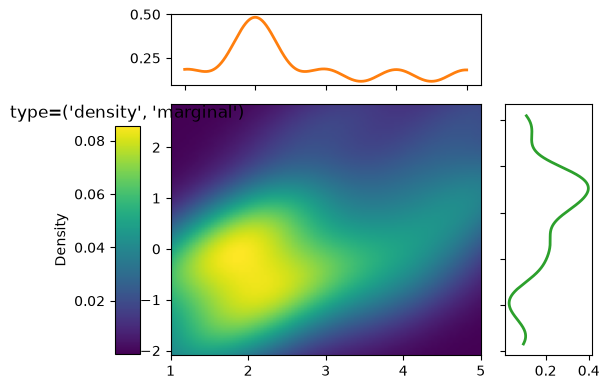

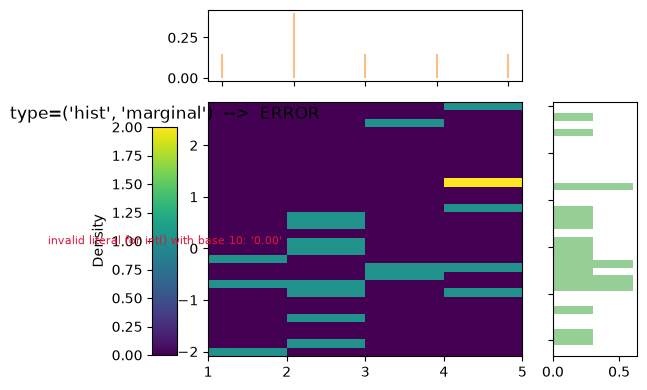

In [ ]:
show_types_2d(RV(Poisson(3) * Normal()).sim(20), TWO_D_TYPES,
           "RV(Poisson(3) * Normal()).sim(20)")

--- RV(Poisson(3) * Normal()).sim(10000) ---


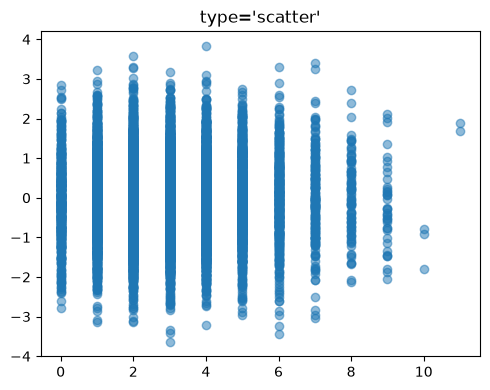

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


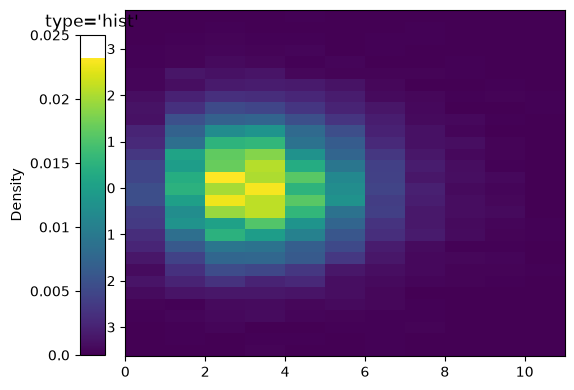

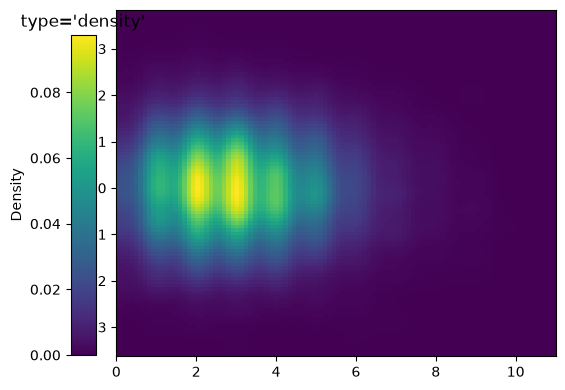

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


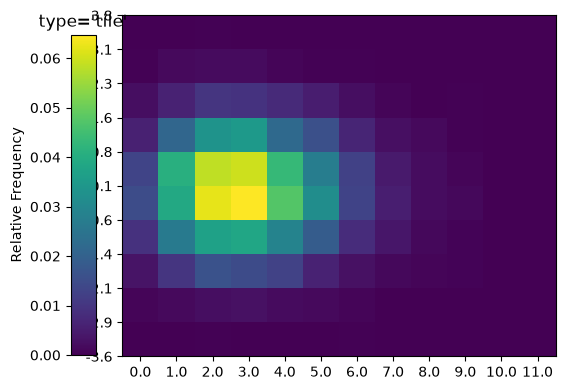

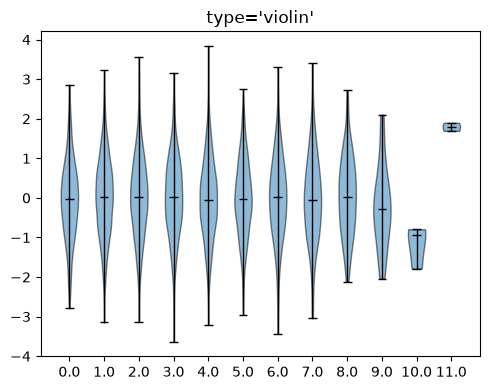

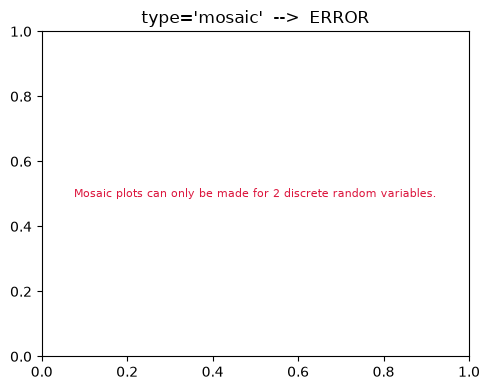

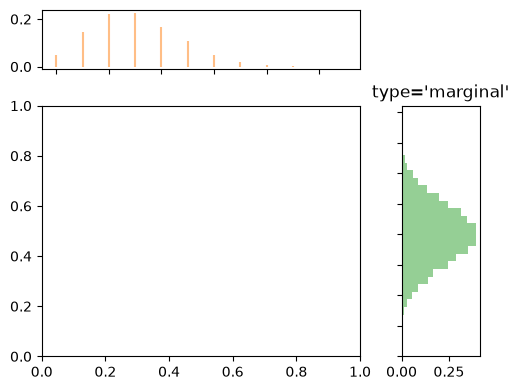

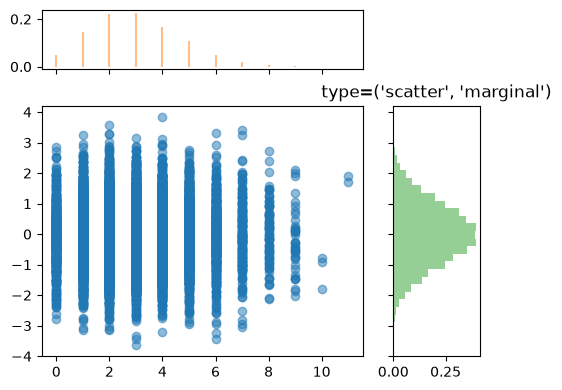

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


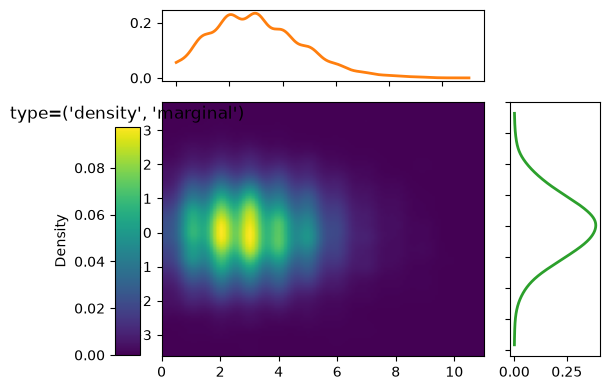

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


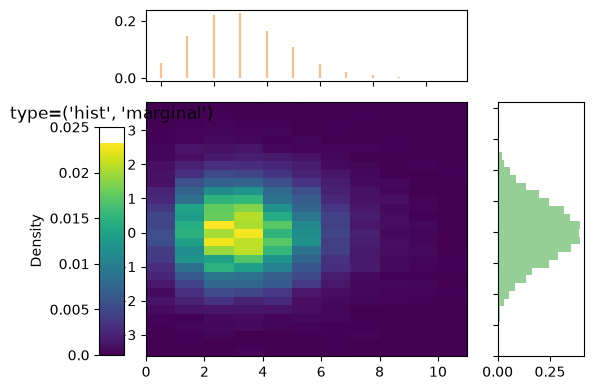

In [ ]:
show_types_2d(RV(Poisson(3) * Normal()).sim(10000), TWO_D_TYPES,
           "RV(Poisson(3) * Normal()).sim(10000)")

--- RV(Binomial(5,0.3) * Exponential(1)).sim(10000) ---


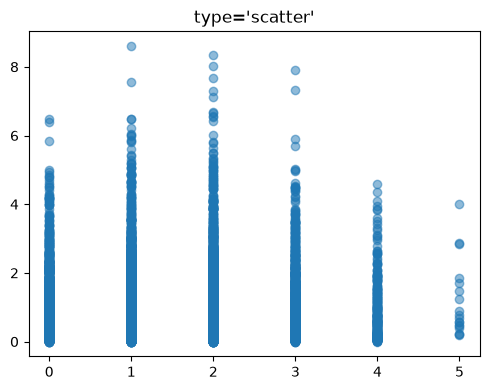

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


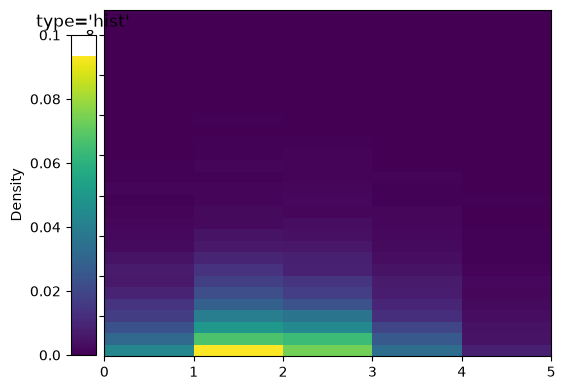

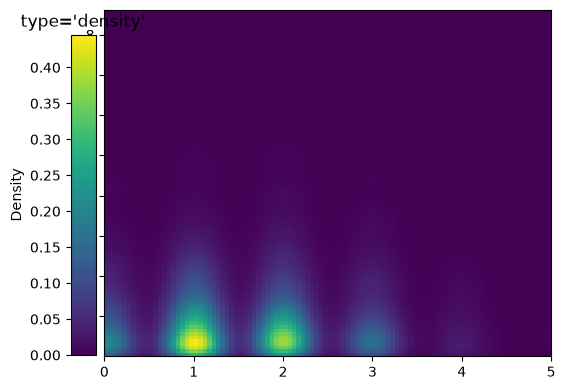

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


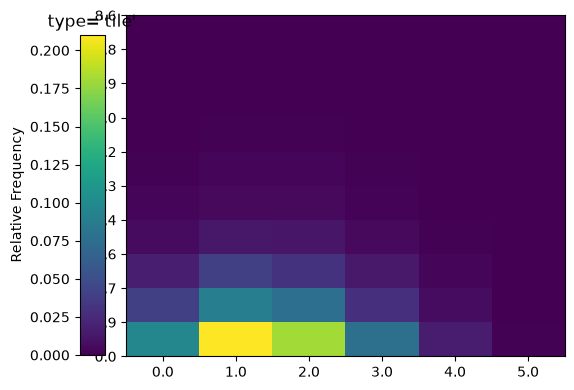

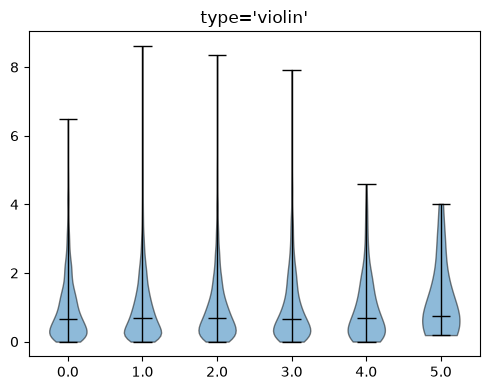

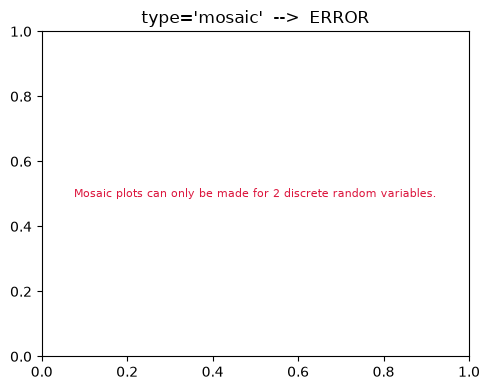

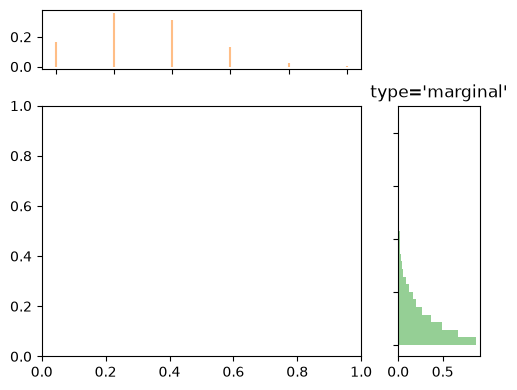

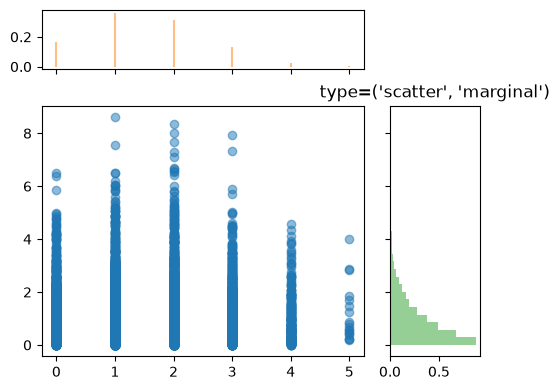

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


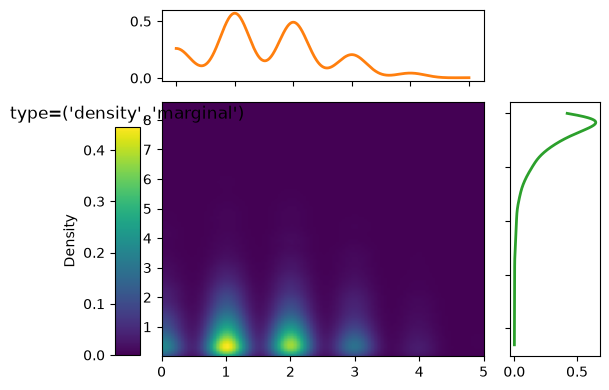

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


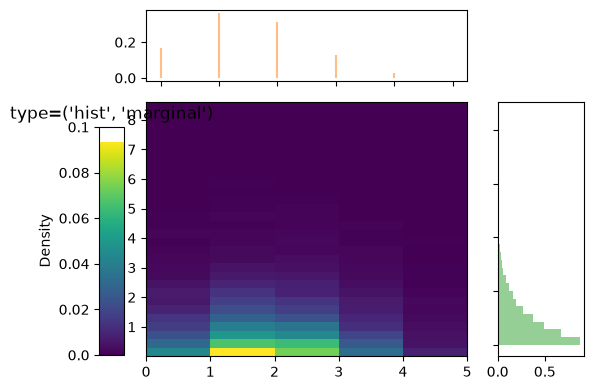

In [ ]:
show_types_2d(RV(Binomial(5, 0.3) * Exponential(1)).sim(10000), TWO_D_TYPES,
           "RV(Binomial(5,0.3) * Exponential(1)).sim(10000)")

--- RV(Poisson(3) * Normal()).sim(50)  -- note the 'hist' bug above ---


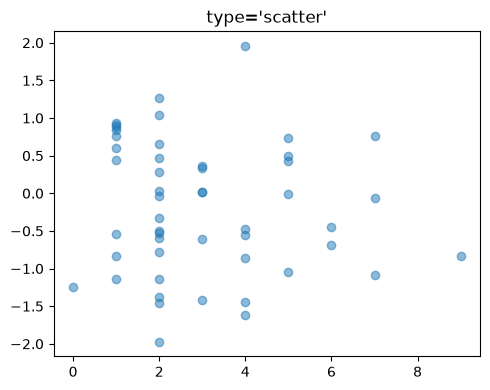

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


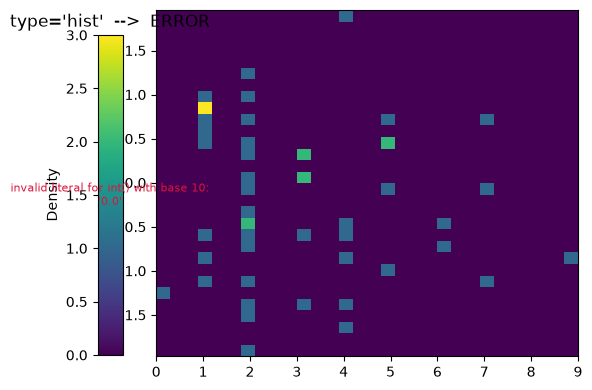

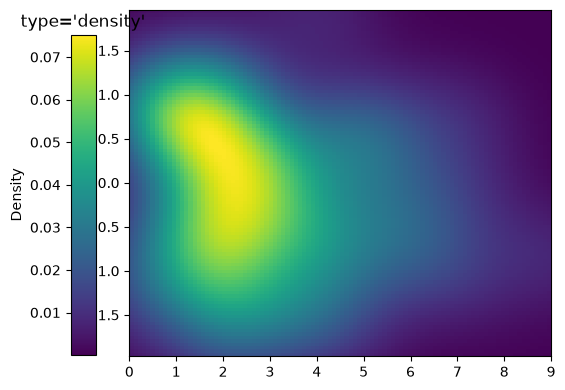

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


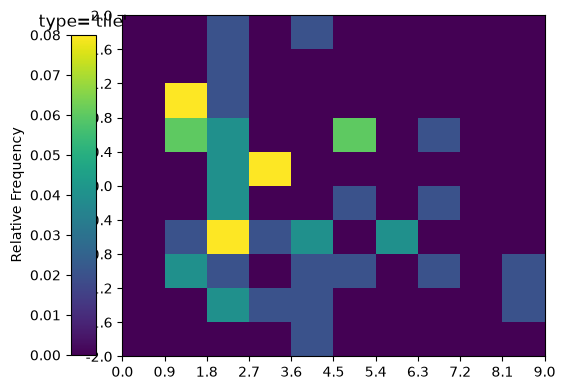

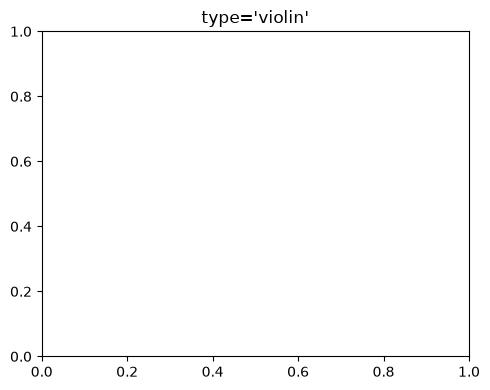

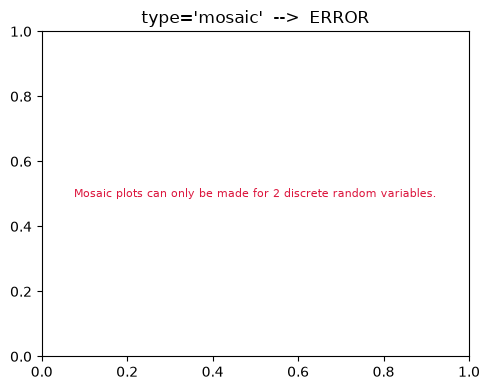

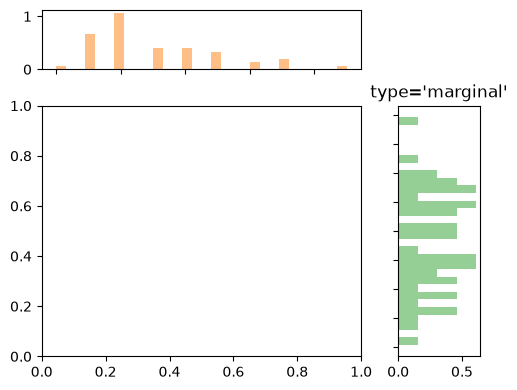

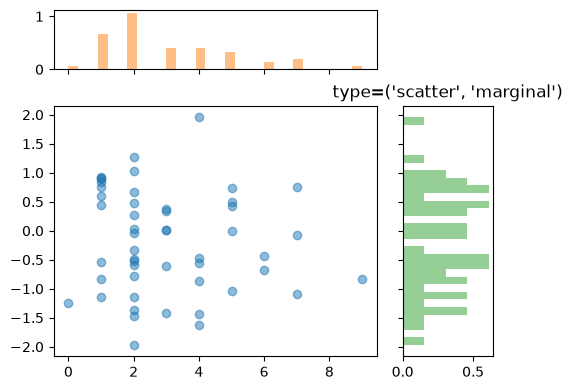

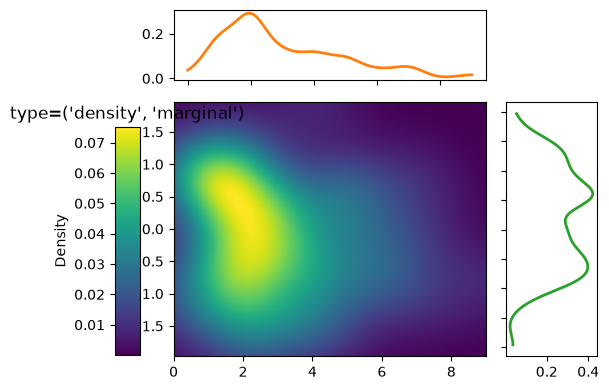

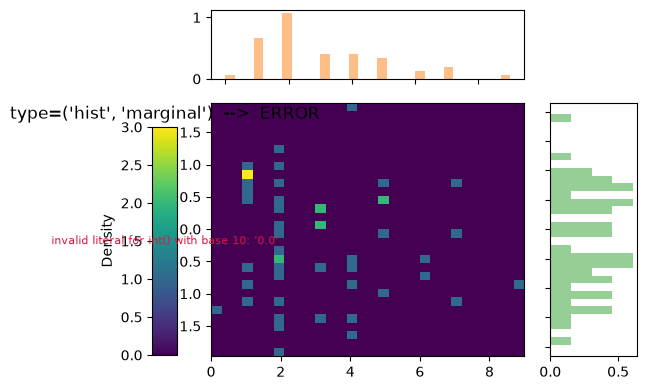

In [ ]:
show_types_2d(RV(Poisson(3) * Normal()).sim(50), TWO_D_TYPES,
           "RV(Poisson(3) * Normal()).sim(50)  -- note the 'hist' bug above")

_Your notes -- best default / reasonable alternatives for 2D discrete x continuous:_\n\n- 

## 2D continuous x discrete

--- RV(Normal() * Poisson(3)).sim(10000) ---


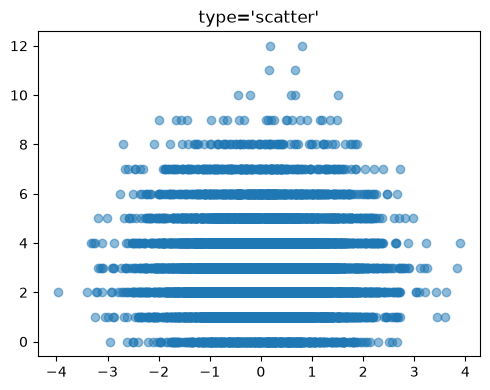

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


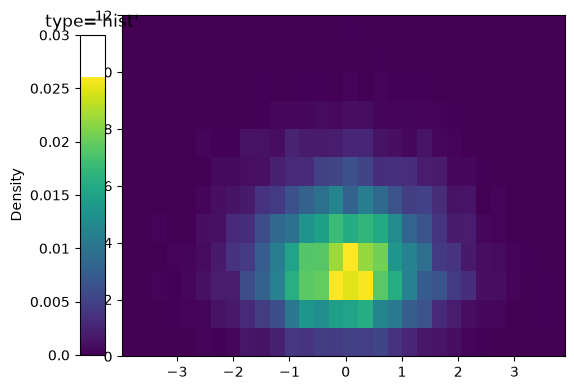

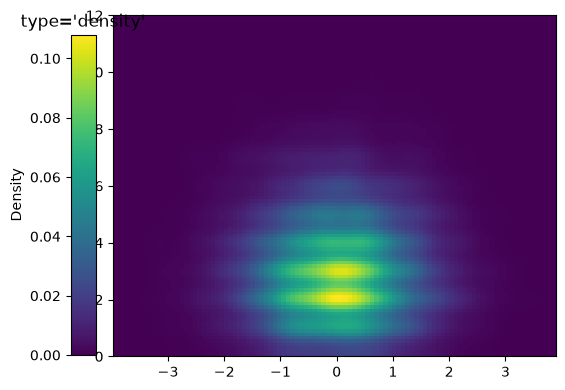

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


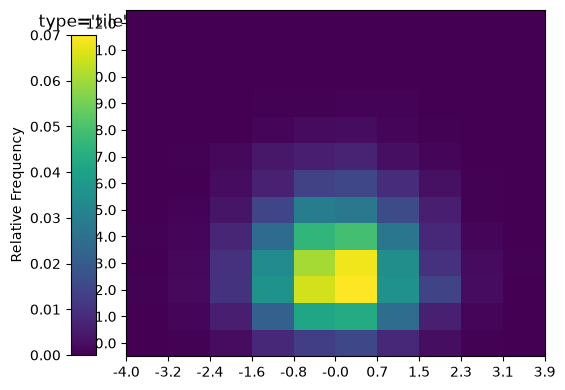

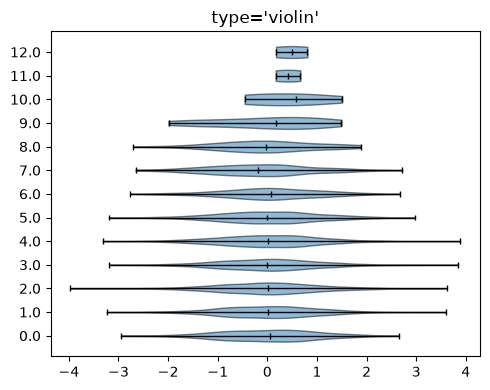

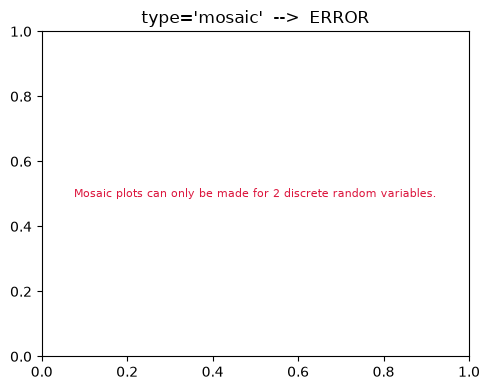

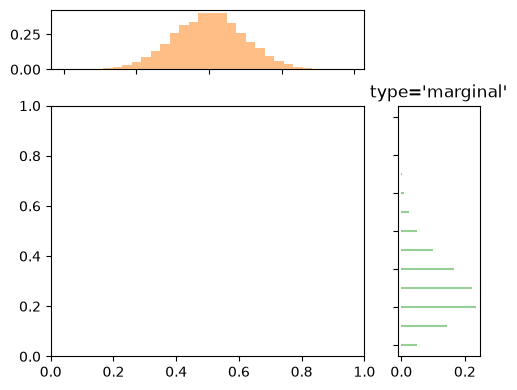

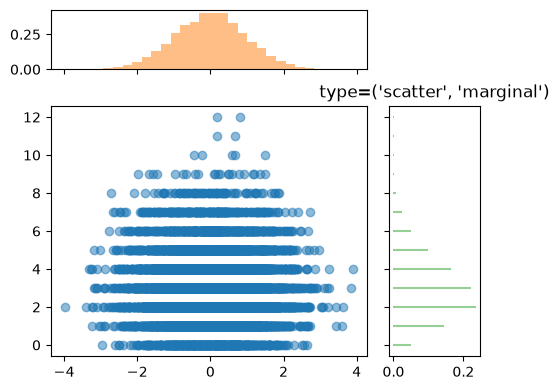

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


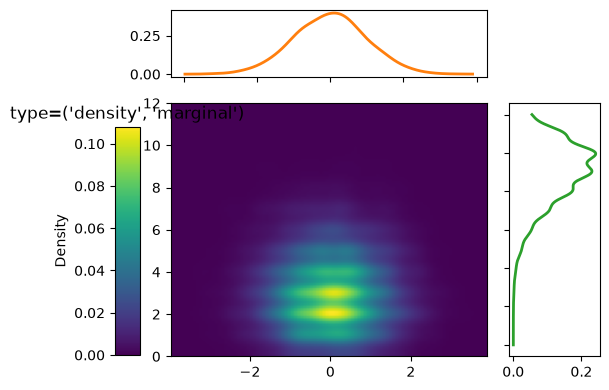

C:\Users\agw07\AppData\Local\Temp\ipykernel_7680\2129978478.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


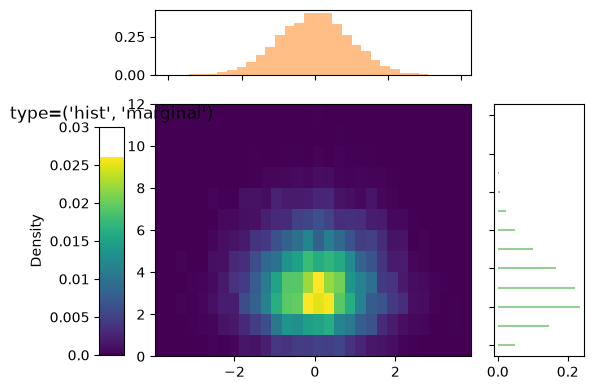

In [ ]:
show_types_2d(RV(Normal() * Poisson(3)).sim(10000), TWO_D_TYPES,
           "RV(Normal() * Poisson(3)).sim(10000)")

_Your notes -- best default / reasonable alternatives for 2D continuous x discrete:_

- Is this meaningfully different from discrete x continuous (just axes swapped), or
  should the two share one row/default in the lookup table?


## Process time point, discrete-valued

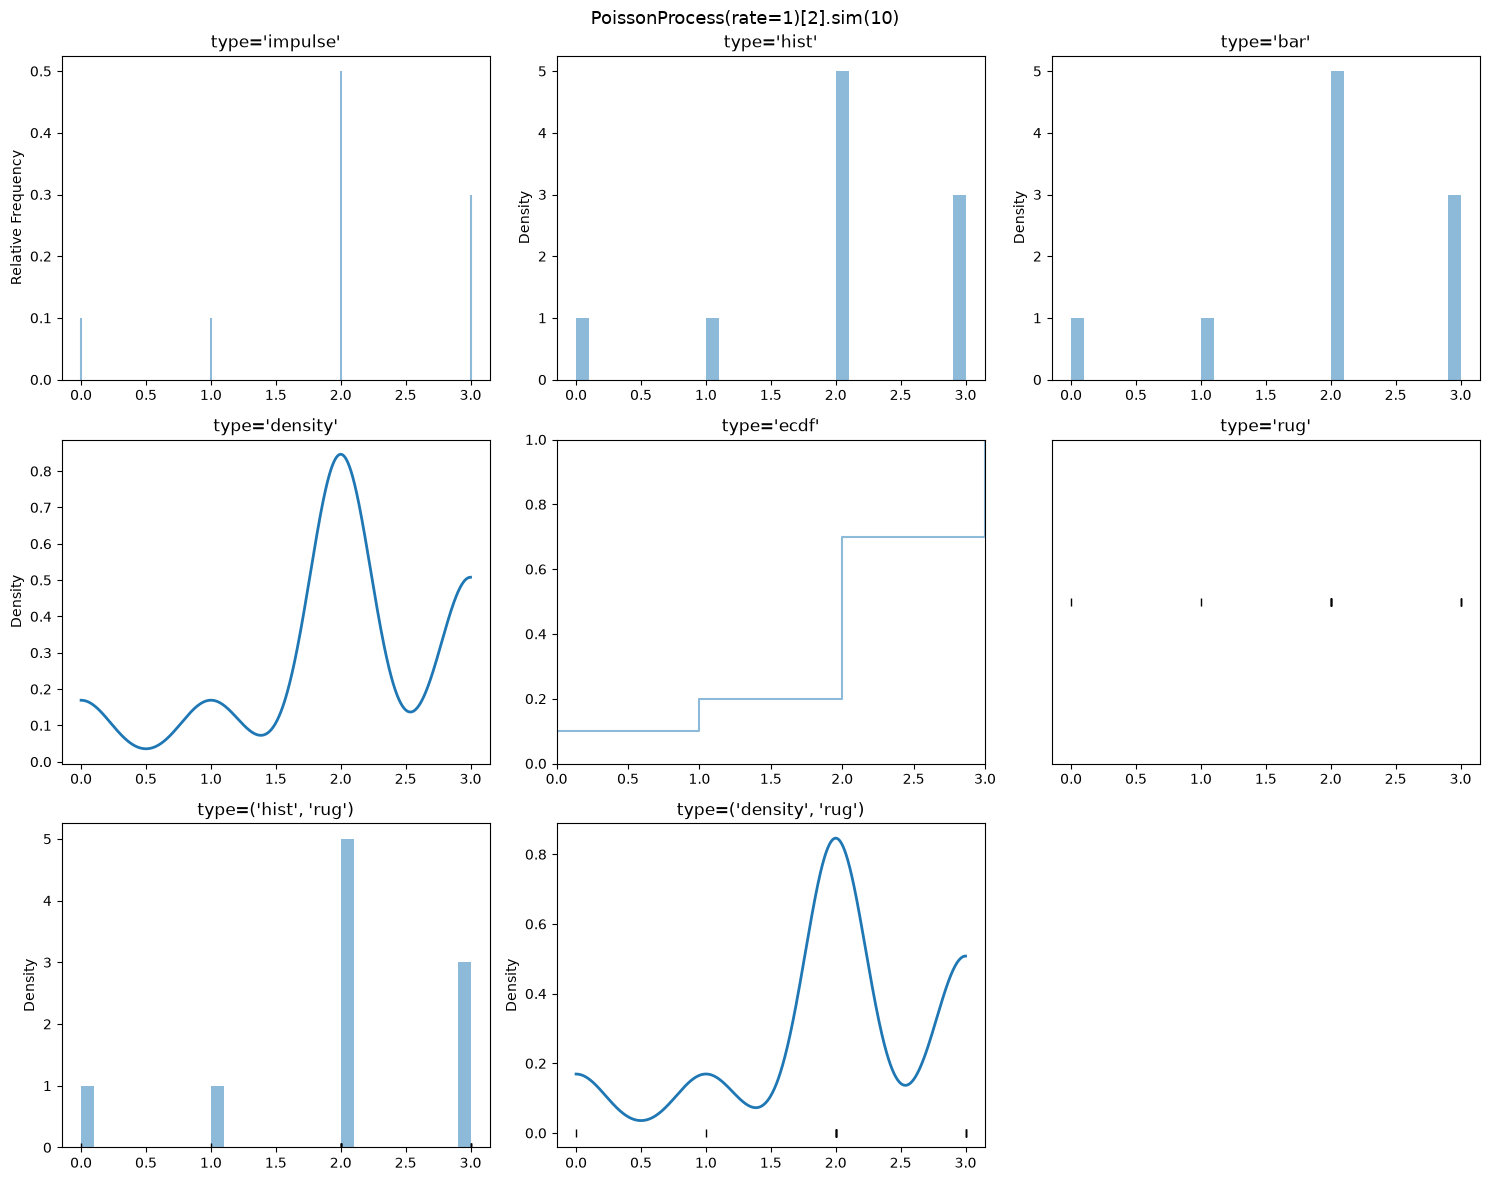

In [ ]:
show_types(PoissonProcess(rate=1)[2].sim(10), ONE_D_TYPES,
           "PoissonProcess(rate=1)[2].sim(10)")

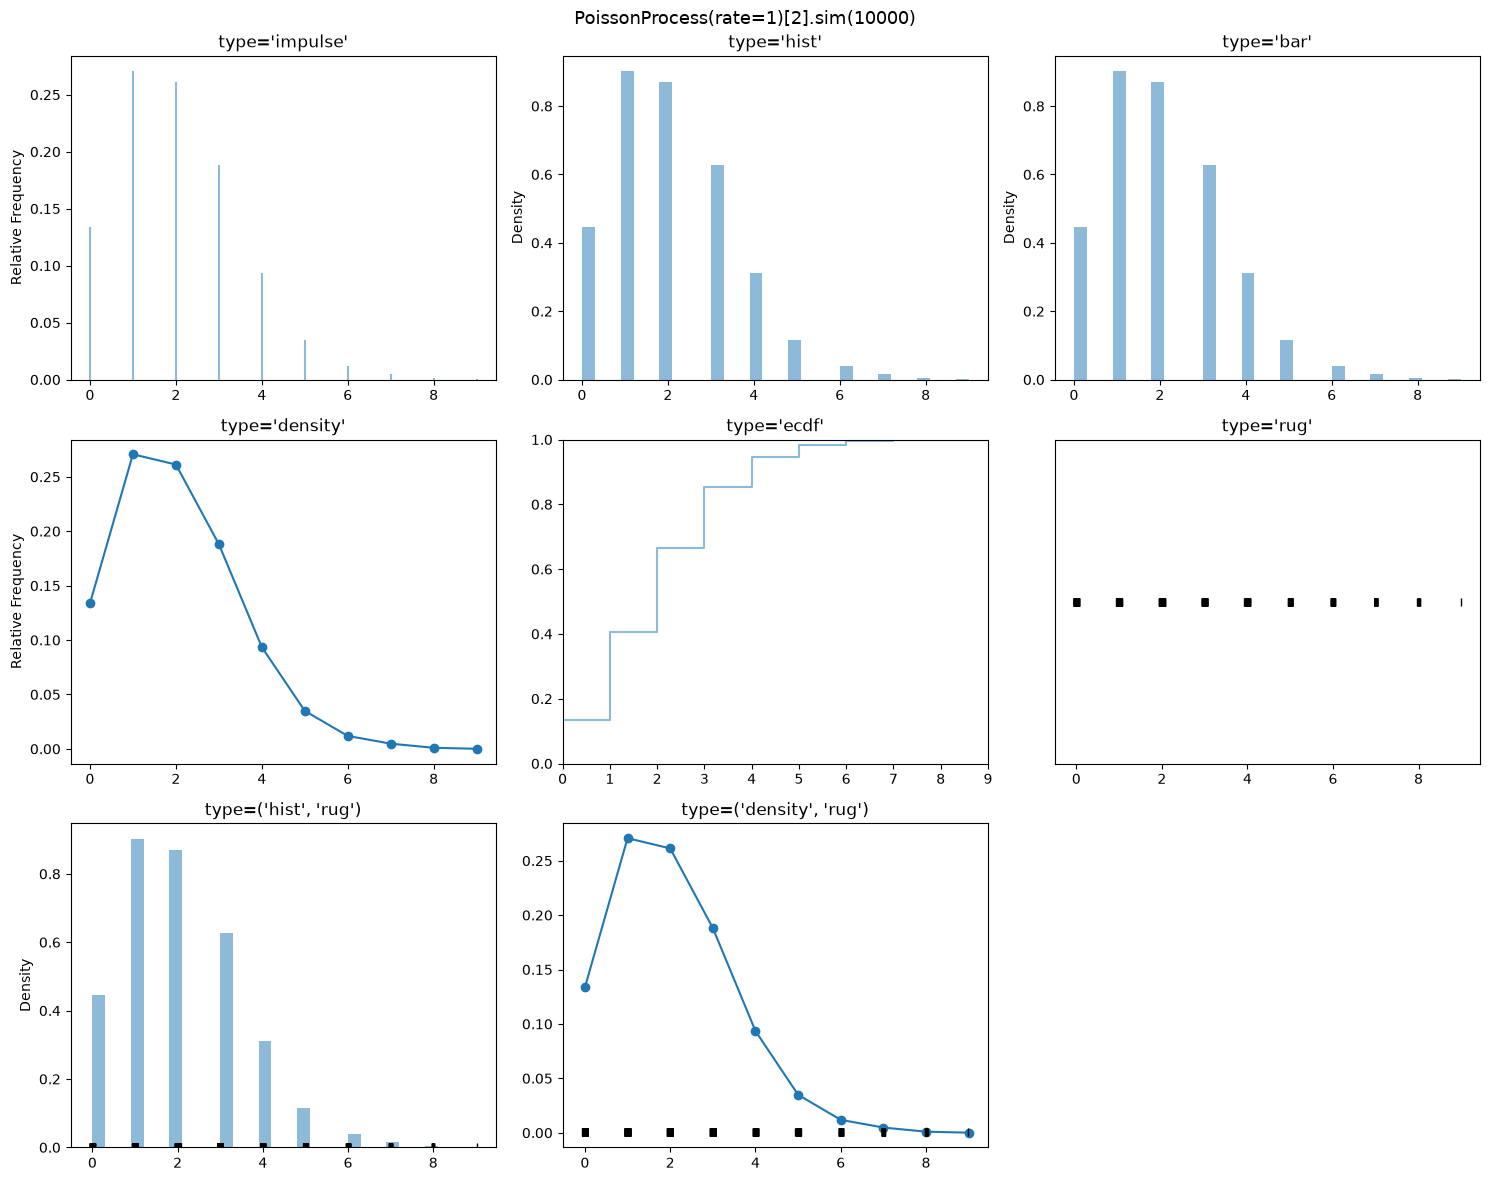

In [ ]:
show_types(PoissonProcess(rate=1)[2].sim(10000), ONE_D_TYPES,
           "PoissonProcess(rate=1)[2].sim(10000)")

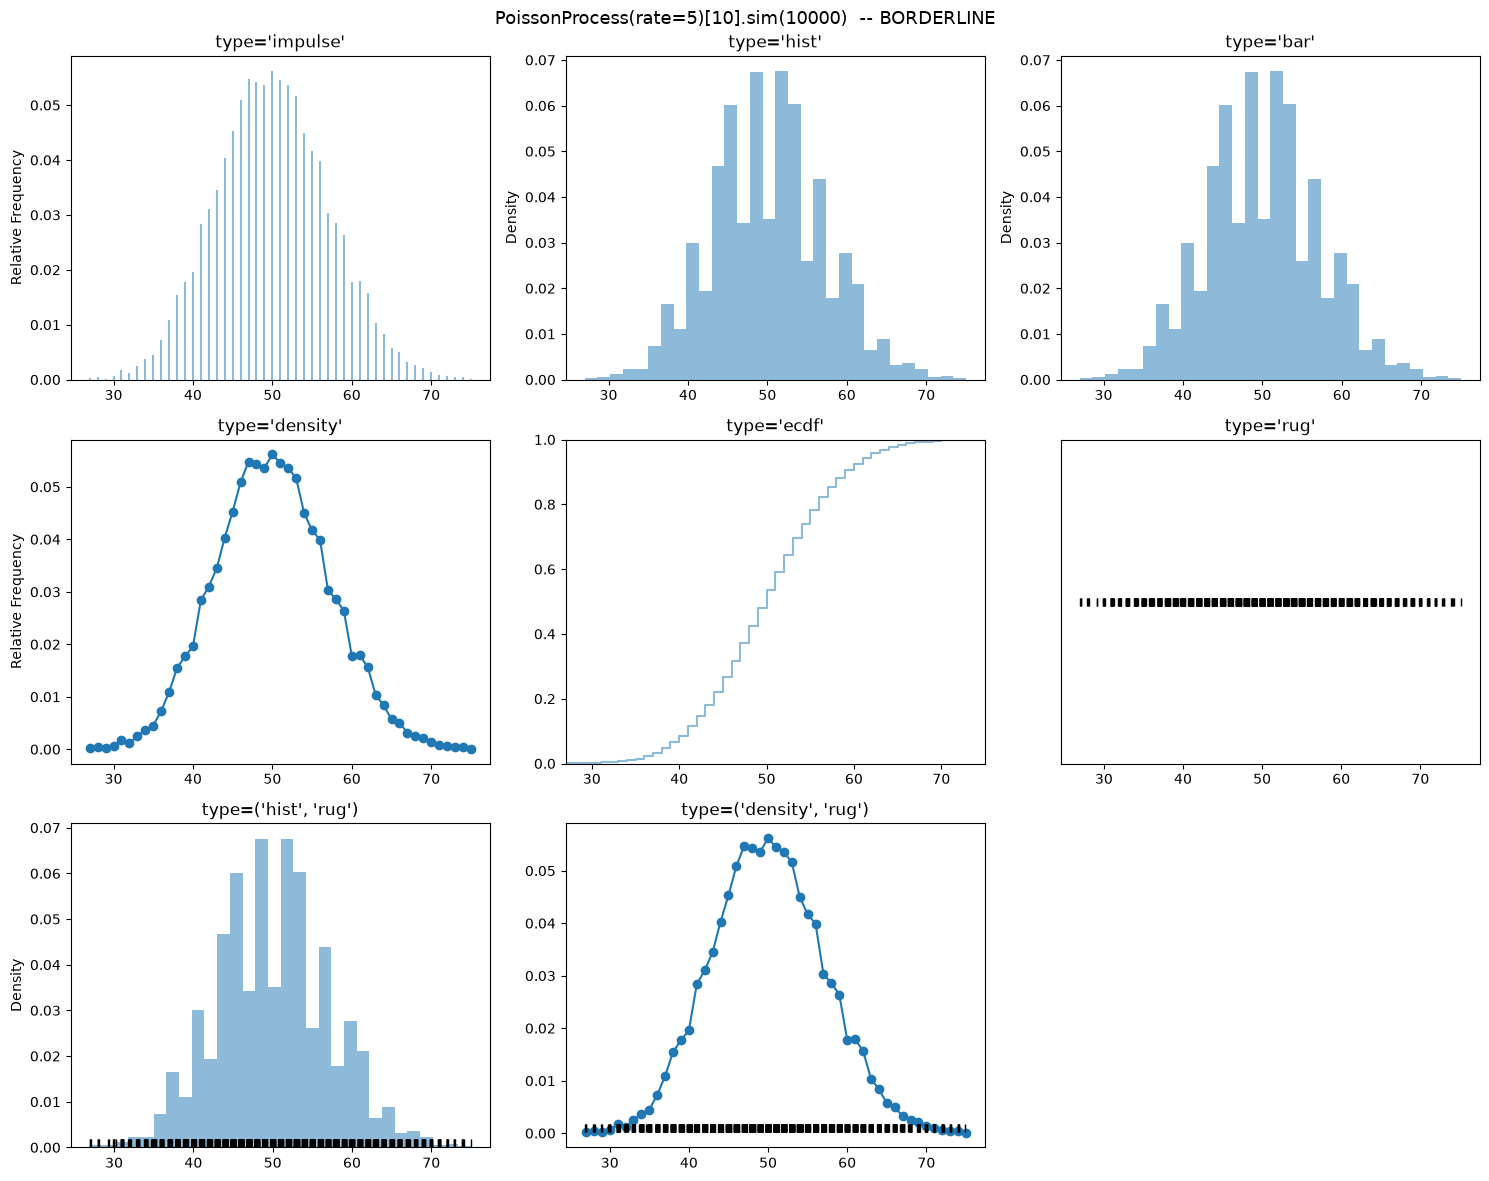

In [ ]:
# Borderline: rate=5 at t=10 means mean count = 50, a wider discrete support.
show_types(PoissonProcess(rate=5)[10].sim(10000), ONE_D_TYPES,
           "PoissonProcess(rate=5)[10].sim(10000)  -- BORDERLINE")

_Your notes -- best default / reasonable alternatives for process time point, discrete-valued:_\n\n- 

## Process time point, continuous-valued

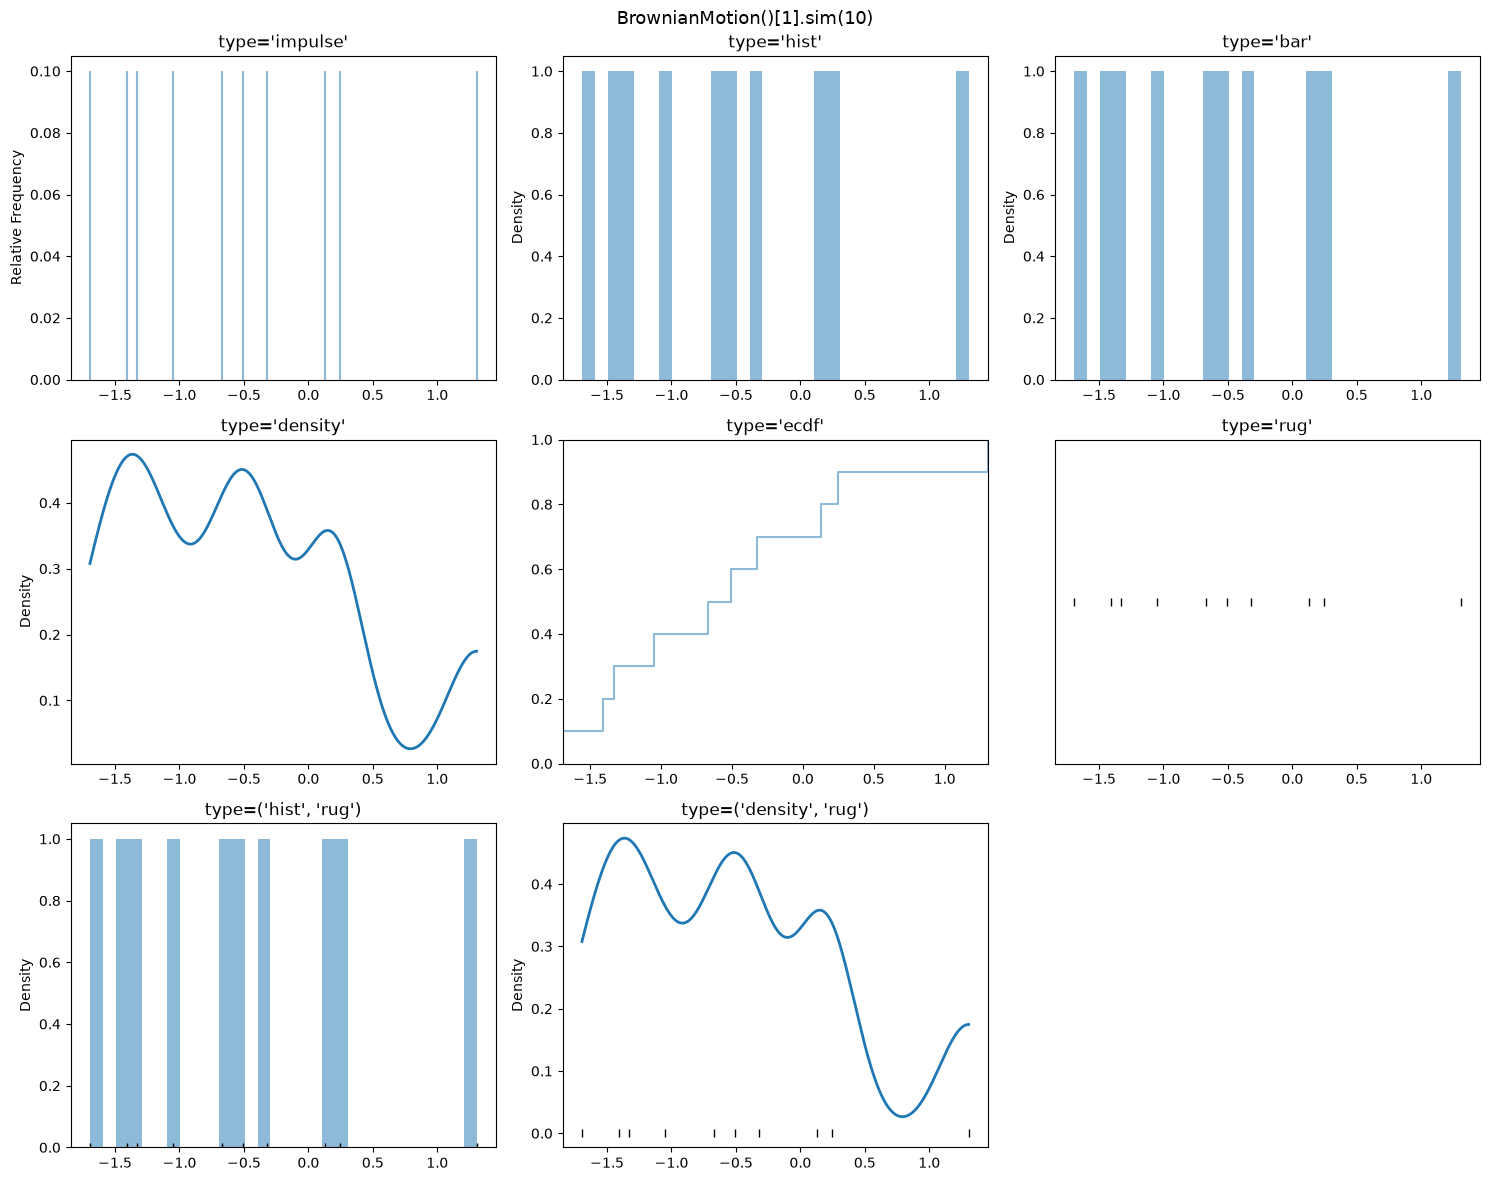

In [ ]:
show_types(BrownianMotion()[1].sim(10), ONE_D_TYPES,
           "BrownianMotion()[1].sim(10)")

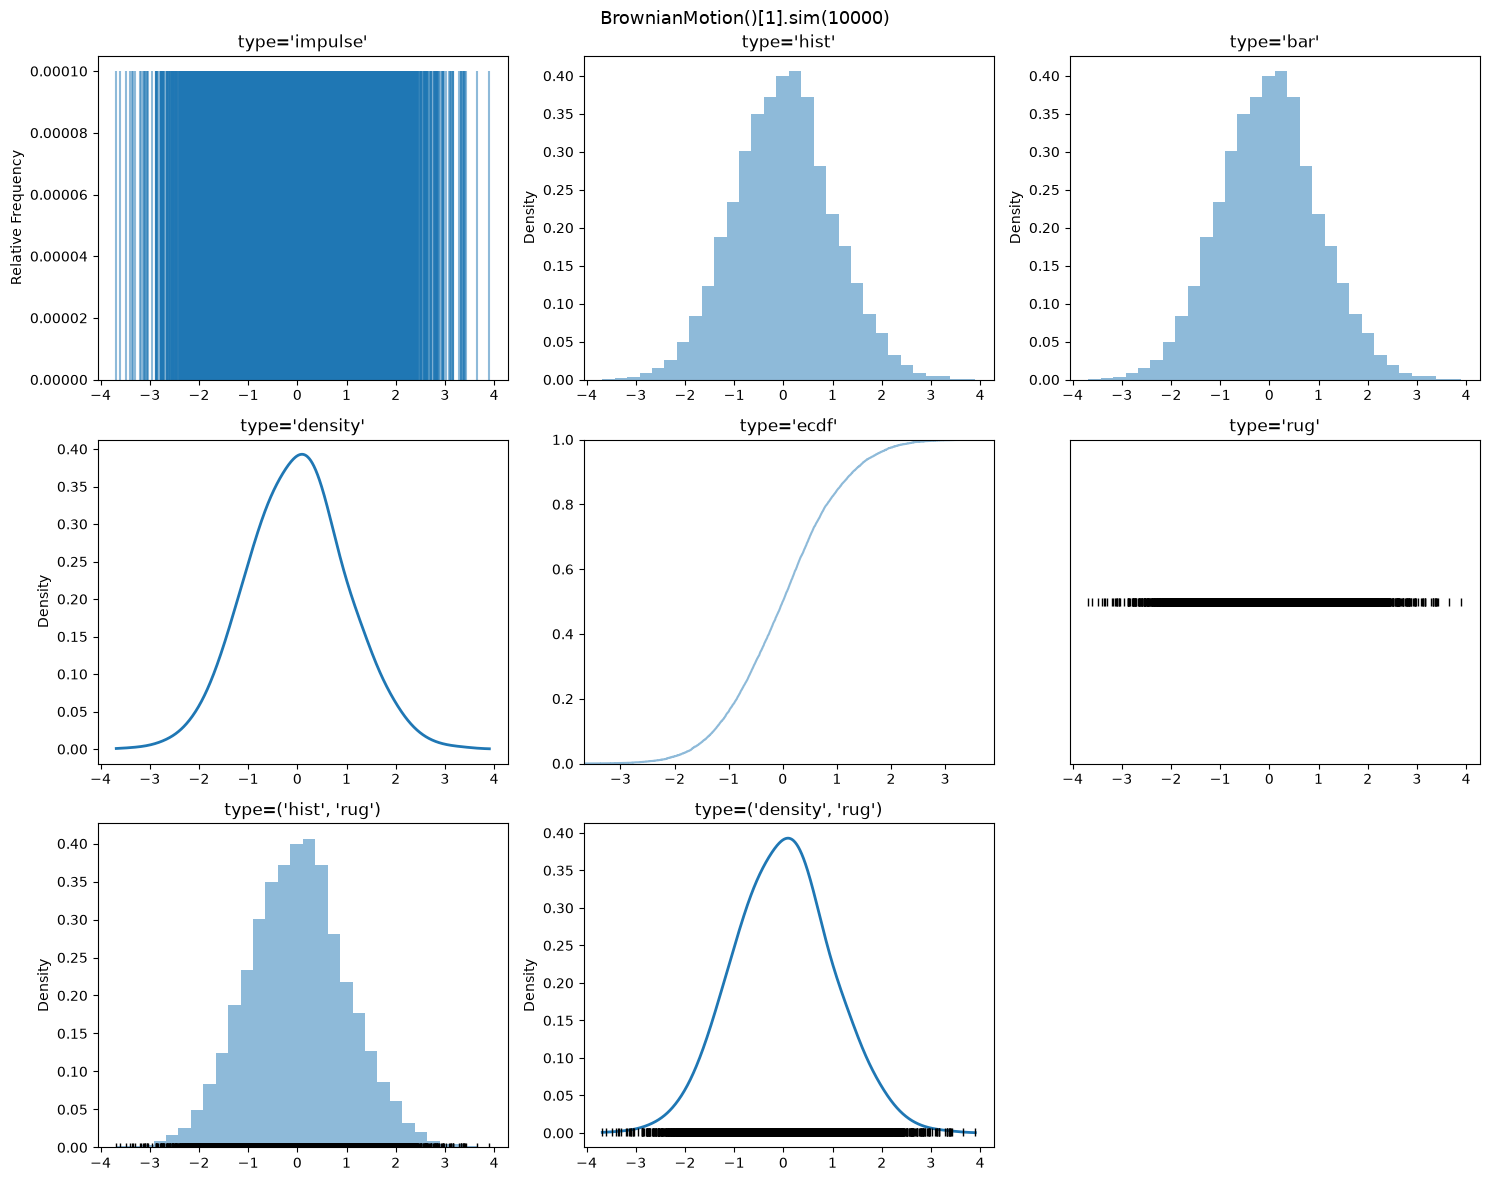

In [ ]:
show_types(BrownianMotion()[1].sim(10000), ONE_D_TYPES,
           "BrownianMotion()[1].sim(10000)")

_Your notes -- best default / reasonable alternatives for process time point, continuous-valued:_\n\n- 

## Overlay behavior

Each of these is deliberately run as **two (or three) `.plot()` calls in a single
cell**, matching how a user would actually layer two simulations on the same axes
in one notebook cell.

**1. Two 1D continuous impulses/histograms overlaid -- should overlay cleanly:**

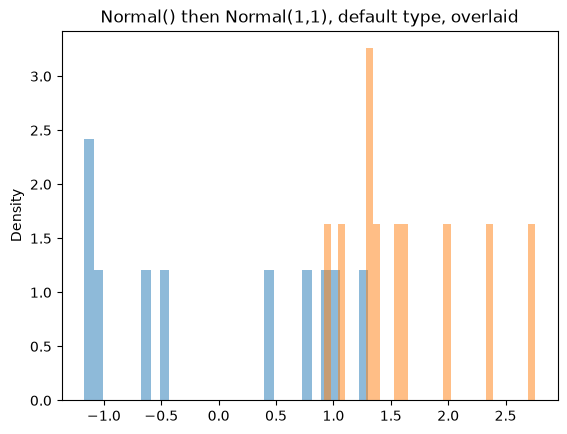

In [ ]:
RV(Normal()).sim(10).plot()
RV(Normal(1, 1)).sim(10).plot()
plt.title("Normal() then Normal(1,1), default type, overlaid")
plt.show()

**2. Two 1D discrete impulses overlaid -- should overlay cleanly:**

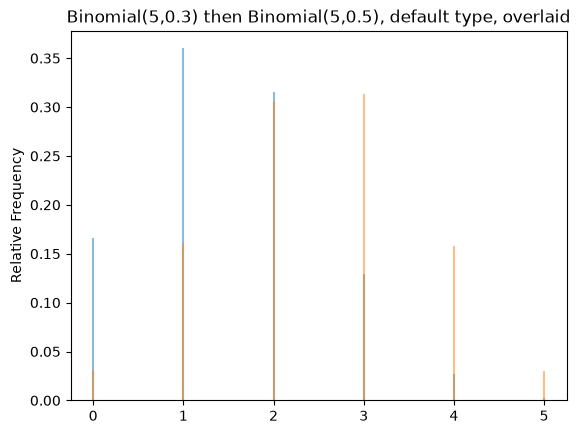

In [ ]:
RV(Binomial(5, 0.3)).sim(10000).plot()
RV(Binomial(5, 0.5)).sim(10000).plot()
plt.title("Binomial(5,0.3) then Binomial(5,0.5), default type, overlaid")
plt.show()

**3. Two 2D scatter plots overlaid -- should overlay cleanly:**

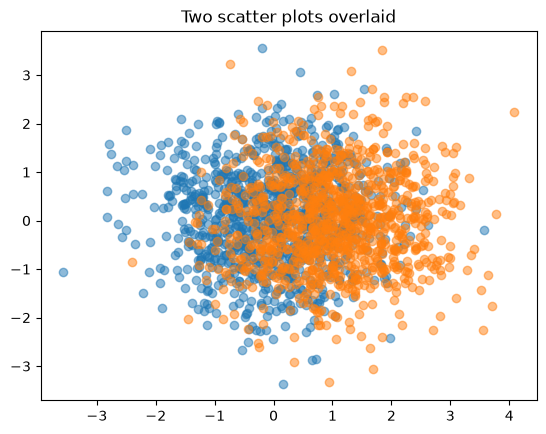

In [ ]:
RV(Normal() * Normal()).sim(1000).plot('scatter')
RV(Normal(1, 1) * Normal()).sim(1000).plot('scatter')
plt.title("Two scatter plots overlaid")
plt.show()

**4. Two 2D tile plots overlaid -- overlay attempted, readability warning expected.**
`tile` uses `ax.matshow`, which fully repaints the axes each call, so the second
call will visually stomp the first rather than blend with it. Look at whether the
result is actually unreadable (supports the case for a runtime warning) or just
mildly confusing.

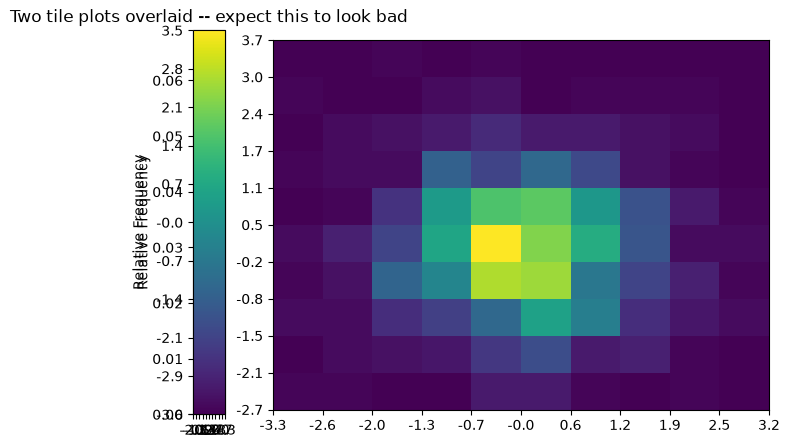

In [ ]:
RV(Normal() * Normal()).sim(1000).plot('tile')
RV(Normal(1, 1) * Normal()).sim(1000).plot('tile')
plt.title("Two tile plots overlaid -- expect this to look bad")
plt.show()

**5. `['scatter', 'marginal']` then a second `.plot()` -- hard error expected (per spec).**
Check whether this fork actually raises an error today. (When this was explored
while assembling this notebook, it did **not** error -- the second `.plot()` call
just quietly drew a new scatter+marginal layout back onto the leftover marginal
axes from the first call, producing a garbled figure instead of failing loudly.
Confirm that's still the behavior you see, since the design assumes a hard error
here.)

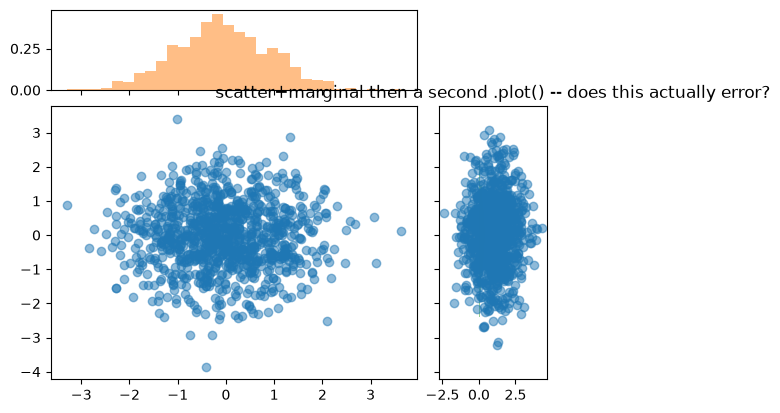

In [ ]:
RV(Normal() * Normal()).sim(1000).plot(['scatter', 'marginal'])
RV(Normal(1, 1) * Normal()).sim(1000).plot()
plt.title("scatter+marginal then a second .plot() -- does this actually error?")
plt.show()

**6/7. Categorical BoxModel overlay + baseline plot calls, exactly as listed in the task.**
Per the finding at the top of this notebook, both of these are expected to raise
`AttributeError: 'str' object has no attribute 'plot'` today, since `.plot()`
requires an `RV`, and string-valued RVs aren't handled by any plot type. This is
the empirical basis for saying the "1D categorical/string" row currently has
**no working default** -- it needs new plotting code before `classify_data` can
route to it.

BoxModel(['H','T']).sim(10).plot() raised: Exception('Only simulations of random variables (RV) can be plotted, but you simulated from a probability space. You must first define a RV on your probability space and simulate it. Then call .plot() on those simulations.')
RV(BoxModel(['H','T'])).sim(10).plot() raised: AttributeError("'str' object has no attribute 'plot'")


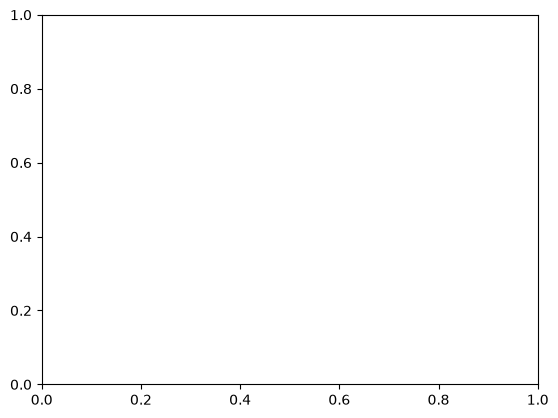

In [ ]:
try:
    BoxModel(['H', 'T']).sim(10).plot()
except Exception as e:
    print("BoxModel(['H','T']).sim(10).plot() raised:", repr(e))

try:
    RV(BoxModel(['H', 'T'])).sim(10).plot()
except Exception as e:
    print("RV(BoxModel(['H','T'])).sim(10).plot() raised:", repr(e))

BoxModel(['H','T']).sim(10000).plot() raised: Exception('Only simulations of random variables (RV) can be plotted, but you simulated from a probability space. You must first define a RV on your probability space and simulate it. Then call .plot() on those simulations.')
RV(BoxModel(['H','T'])).sim(10000).plot() raised: AttributeError("'str' object has no attribute 'plot'")


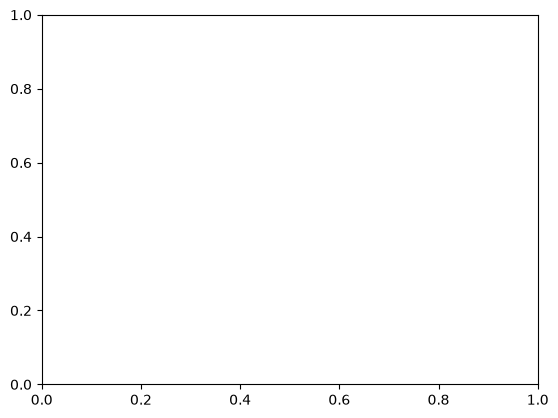

In [ ]:
try:
    BoxModel(['H', 'T']).sim(10000).plot()
except Exception as e:
    print("BoxModel(['H','T']).sim(10000).plot() raised:", repr(e))

try:
    RV(BoxModel(['H', 'T'])).sim(10000).plot()
except Exception as e:
    print("RV(BoxModel(['H','T'])).sim(10000).plot() raised:", repr(e))

_Your notes -- overlay behavior:_\n\n- 

---
## Step 2 -- Lookup table (fill in after looking at the plots above)

| Data configuration | Small n default | Small n alternatives | Large n default | Large n alternatives |
|---|---|---|---|---|
| 1D discrete-ish | | | | |
| 1D continuous-ish | | | | |
| 2D discrete x discrete | | | | |
| 2D continuous x continuous | | | | |
| 2D discrete x continuous | | | | |
| 2D continuous x discrete | | | | |
| Process time point, discrete-valued | | | | |
| Process time point, continuous-valued | | | | |
| 1D categorical/string | | | | |

## Step 3 -- Suggestion message wording

Draft the message printed when a default plot type is chosen automatically.
Example starting point:

> "Showing an impulse plot (the default for this type of data). You might also try `type='hist'` or `type='density'`."

Decide:
- Always show it, first-time-only, or opt-out via `verbose=False`?
- Does it change if the user overlays multiple `.plot()` calls in one cell (i.e., should it only fire once per axes, not once per call)?

_Draft:_

>

## Step 4 -- Thresholds

`n_unique_threshold` (default 40) and `n_small_threshold` (default 100) --
after seeing the borderline cases above (`Poisson(20)`, `PoissonProcess(rate=5)[10]`),
do these numbers feel right? Write the reasoning for whatever is chosen; it goes
into `DECISIONS.md`.

- `n_unique_threshold`:
- `n_small_threshold`:
